# **EEG-IP sex-differences paper**

### Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, ttest_ind, mannwhitneyu, pearsonr)
from scipy import stats as _sc
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import os
import umap.umap_ as umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.stats import chi2_contingency
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.lines import Line2D
import pingouin as pg

# **Data setup:** Load data

In [2]:
main_df = pd.read_csv(f"../../datasets/sex_diff_main.csv") 

In [3]:
main_df.columns

Index(['subject', 'front_gamma_6', 'front_gamma_12', 'front_gamma_18',
       'dmn_con_6', 'dmn_con_12', 'attn_con_6', 'attn_con_12', 'visual_con_6',
       'visual_con_12', 'auditory_con_6', 'auditory_con_12', 'lang_comp_con_6',
       'lang_comp_con_12', 'speech_con_6_left', 'speech_con_12_left',
       'gamma_lat_6', 'gamma_lat_12', 'gamma_lat_18', 'site', 'group_type',
       'outcome', 'sex', 'hc_class', 'lpa_class', 'receptive_6',
       'expressive_6', 'receptive_12', 'expressive_12', 'receptive_18',
       'expressive_18', 'receptive_24', 'expressive_24', 'receptive_36',
       'expressive_36', 'nonverbal_iq_6'],
      dtype='object')

In [4]:
# Lannguage variables
language_vars = ['receptive_6', 'expressive_6', 'receptive_12',
       'expressive_12', 'receptive_18', 'expressive_18', 'receptive_24',
       'expressive_24', 'receptive_36', 'expressive_36', 'nonverbal_iq_6']
cleaned_language_vars= ['Receptive MSEL 6 months', 'Expressive MSEL 6 months',
              'Receptive MSEL 12 months', 'Expressive MSEL 12 months',
              'Receptive MSEL 18 months', 'Expressive MSEL 18 months',
              'Receptive MSEL 24 months', 'Expressive MSEL 24 months',
              'Receptive MSEL 36 months', 'Expressive MSEL 36 months',
              'NVIQ']

In [5]:
# EEG variables includes 12mo and 18mo frontal gamma / lateralization
eeg_vars = [
    'front_gamma_6', 'front_gamma_12', 'front_gamma_18',
    'dmn_con_6', 'dmn_con_12',
    'attn_con_6', 'attn_con_12',
    'visual_con_6', 'visual_con_12',
    'auditory_con_6', 'auditory_con_12',
    'lang_comp_con_6', 'lang_comp_con_12',
    'speech_con_6_left', 'speech_con_12_left',
    'gamma_lat_6', 'gamma_lat_12', 'gamma_lat_18',
]
clean_eeg_vars = [
    'Frontal Gamma Power 6mo', 'Frontal Gamma Power 12mo', 'Frontal Gamma Power 18mo',
    'DMN 6mo', 'DMN 12mo',
    'Attention Network 6mo', 'Attention Network 12mo',
    'Visual Network 6mo', 'Visual Network 12mo',
    'Auditory Network 6mo', 'Auditory Network 12mo',
    'Language Network 6mo', 'Language Network 12mo',
    'Speech Network 6mo', 'Speech Network 12mo',
    'Power Lateralization 6mo', 'Power Lateralization 12mo', 'Power Lateralization 18mo',
]


In [6]:
# Clean up column names
clean_column_name_mapping = {
  'expressive_6':  'Expressive MSEL 6 months',
  'expressive_12': 'Expressive MSEL 12 months',
  'expressive_18': 'Expressive MSEL 18 months',
  'expressive_24': 'Expressive MSEL 24 months',
  'expressive_36': 'Expressive MSEL 36 months',
  'receptive_6':   'Receptive MSEL 6 months',
  'receptive_12':  'Receptive MSEL 12 months',
  'receptive_18':  'Receptive MSEL 18 months',
  'receptive_24':  'Receptive MSEL 24 months',
  'receptive_36':  'Receptive MSEL 36 months',
  'nonverbal_iq_6': 'NVIQ',
  'lpa_class': 'LPA Class',
  'hc_class':  'HC Class',
 # EEG variables frontal gamma at all 3 timepoints
  'front_gamma_6':  'Frontal Gamma Power 6mo',
  'front_gamma_12': 'Frontal Gamma Power 12mo',
  'front_gamma_18': 'Frontal Gamma Power 18mo',
  'dmn_con_6':  'DMN 6mo',
  'dmn_con_12': 'DMN 12mo',
  'attn_con_6':  'Attention Network 6mo',
  'attn_con_12': 'Attention Network 12mo',
  'visual_con_6':  'Visual Network 6mo',
  'visual_con_12': 'Visual Network 12mo',
  'auditory_con_6':  'Auditory Network 6mo',
  'auditory_con_12': 'Auditory Network 12mo',
  'lang_comp_con_6':  'Language Network 6mo',
  'lang_comp_con_12': 'Language Network 12mo',
  'speech_con_6_left':  'Speech Network 6mo',
  'speech_con_12_left': 'Speech Network 12mo',
 # Lateralization at all 3 timepoints
  'gamma_lat_6':  'Power Lateralization 6mo',
  'gamma_lat_12': 'Power Lateralization 12mo',
  'gamma_lat_18': 'Power Lateralization 18mo',
}

# Implement remapping
main_df.rename(columns=clean_column_name_mapping, inplace=True)


In [7]:
neurosubs_df=main_df.copy()

# **Descriptive statistics**

#### Demographics

In [8]:
# Total number of subjects
total_subjects = len(neurosubs_df)
total_subjects

179

c:\Users\gabot\anaconda3\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


##### Autism ASD Diagnosis 

In [9]:
neurosubs_df

,subject,Frontal Gamma Power 6mo,Frontal Gamma Power 12mo,Frontal Gamma Power 18mo,DMN 6mo,DMN 12mo,Attention Network 6mo,Attention Network 12mo,Visual Network 6mo,Visual Network 12mo,...,Expressive MSEL 6 months,Receptive MSEL 12 months,Expressive MSEL 12 months,Receptive MSEL 18 months,Expressive MSEL 18 months,Receptive MSEL 24 months,Expressive MSEL 24 months,Receptive MSEL 36 months,Expressive MSEL 36 months,NVIQ
0,2,-21.420116,-21.506803,-20.711995,-1.179456,-1.811397,-1.291220,-1.819618,NaN,-1.856955,...,5.0,13.0,13.0,22.0,14.0,28.0,21.0,NaN,NaN,7.0
1,3,-21.072590,-21.477770,-21.092442,-1.478355,-1.615233,-1.409049,-1.666511,-1.453274,-1.807008,...,7.0,14.0,14.0,20.0,18.0,27.0,21.0,NaN,NaN,6.5
2,5,-22.141673,-21.923702,NaN,-1.590910,-1.459731,-1.572270,-1.474575,-1.464652,-1.562207,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
3,6,-21.630370,-21.010051,-21.793934,-1.613312,-1.636706,-1.519757,-1.629096,-1.398602,-1.597107,...,4.0,13.0,12.0,20.0,21.0,28.0,27.0,NaN,NaN,6.0
4,8,-21.588120,-22.242941,-22.352703,-1.573957,-1.732826,-1.582186,-1.682690,-1.650752,-1.743044,...,5.0,11.0,8.0,20.0,21.0,28.0,24.0,NaN,NaN,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,738,NaN,-21.061195,NaN,NaN,-1.724801,NaN,-1.756632,NaN,-1.476912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,744,NaN,-20.921363,NaN,NaN,-1.469632,NaN,-1.493794,NaN,-1.494525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,749,NaN,-21.403537,NaN,NaN,-1.605836,NaN,-1.578385,NaN,-1.699922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,750,NaN,-20.462636,NaN,NaN,-1.536589,NaN,-1.525664,NaN,-1.570329,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
neurosubs_df["outcome"].value_counts()


outcome
no-asd    145
asd        30
Name: count, dtype: int64

##### Autism Risk 

In [11]:
neurosubs_df["group_type"].value_counts()

group_type
ELA    90
TLA    89
Name: count, dtype: int64

##### Site counts

In [12]:
neurosubs_df["site"].value_counts()

site
london        96
washington    83
Name: count, dtype: int64

##### Sex differences

In [13]:
neurosubs_df[["sex"]].value_counts()


sex
M      91
F      88
Name: count, dtype: int64

##### Break down across variables

In [14]:
comprehensive_table=neurosubs_df.groupby(["group_type", "site", "sex", "outcome"]).outcome.value_counts().reset_index(name='count')
comprehensive_table = comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
comprehensive_table

,ASD Likelihood,Site,Sex,ASD Diagnosis,count
0,ELA,london,F,asd,5
1,ELA,london,F,no-asd,25
2,ELA,london,M,asd,11
3,ELA,london,M,no-asd,10
4,ELA,washington,F,asd,7
5,ELA,washington,F,no-asd,6
6,ELA,washington,M,asd,4
7,ELA,washington,M,no-asd,22
8,TLA,london,F,no-asd,27
9,TLA,london,M,no-asd,18


##### Demographics per sex

In [15]:
sex_comprehensive_table=neurosubs_df.groupby(["sex", "group_type","outcome"]).outcome.value_counts().reset_index(name='count')
sex_comprehensive_table = sex_comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
sex_comprehensive_table

,Sex,ASD Likelihood,ASD Diagnosis,count
0,F,ELA,asd,12
1,F,ELA,no-asd,31
2,F,TLA,asd,1
3,F,TLA,no-asd,43
4,M,ELA,asd,15
5,M,ELA,no-asd,32
6,M,TLA,asd,2
7,M,TLA,no-asd,39


##### Demographics per HC clustering group

In [16]:
hc_comprehensive_table=neurosubs_df.groupby(["sex", "group_type","outcome", "HC Class"]).outcome.value_counts().reset_index(name='count')
hc_comprehensive_table = hc_comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
hc_comprehensive_table

,Sex,ASD Likelihood,ASD Diagnosis,HC Class,count
0,F,ELA,asd,0.0,3
1,F,ELA,asd,1.0,2
2,F,ELA,asd,2.0,3
3,F,ELA,no-asd,0.0,3
4,F,ELA,no-asd,1.0,8
5,F,ELA,no-asd,2.0,12
6,F,TLA,asd,1.0,1
7,F,TLA,no-asd,0.0,13
8,F,TLA,no-asd,1.0,11
9,F,TLA,no-asd,2.0,11


##### Demographics per LPA clustering group

In [17]:
lpa_comprehensive_table=neurosubs_df.groupby(["sex", "group_type","outcome", "LPA Class"]).outcome.value_counts().reset_index(name='count')
lpa_comprehensive_table = lpa_comprehensive_table.rename(columns={"group_type": "ASD Likelihood", "site": "Site", "sex":"Sex", "outcome":"ASD Diagnosis"})

# Save as supplementary table
lpa_comprehensive_table

,Sex,ASD Likelihood,ASD Diagnosis,LPA Class,count
0,F,ELA,asd,1.0,3
1,F,ELA,asd,2.0,1
2,F,ELA,asd,3.0,4
3,F,ELA,no-asd,1.0,10
4,F,ELA,no-asd,2.0,2
5,F,ELA,no-asd,3.0,11
6,F,TLA,asd,3.0,1
7,F,TLA,no-asd,1.0,12
8,F,TLA,no-asd,2.0,8
9,F,TLA,no-asd,3.0,15


#### Participants demographics table

In [18]:
# Total sample size
total_n = len(neurosubs_df)

# Create a dictionary to store all the table data
table_data = {
    "Characteristic": [],
    "n": [],
    "%": []
}

# 1. Diagnostic Status
diag_counts = neurosubs_df['outcome'].value_counts()
table_data["Characteristic"].extend(["Diagnostic Status", "asd", "no-asd"])
table_data["n"].extend(["", diag_counts.get("asd", 0), diag_counts.get("no-asd", 0)])
table_data["%"].extend(["", 
                       round(diag_counts.get("asd", 0)/total_n*100, 1),
                       round(diag_counts.get("no-asd", 0)/total_n*100, 1)])

# 2. ASD Likelihood
group_counts = neurosubs_df['group_type'].value_counts()
table_data["Characteristic"].extend(["ASD Likelihood", "TLA", "ELA"])
table_data["n"].extend(["", group_counts.get("TLA", 0), group_counts.get("ELA", 0)])
table_data["%"].extend(["", 
                       round(group_counts.get("TLA", 0)/total_n*100, 1),
                       round(group_counts.get("ELA", 0)/total_n*100, 1)])

# 3. Site
site_counts = neurosubs_df['site'].value_counts()
table_data["Characteristic"].extend(["Site", "london", "washington"])
table_data["n"].extend(["", site_counts.get("london", 0), site_counts.get("washington", 0)])
table_data["%"].extend(["", 
                       round(site_counts.get("london", 0)/total_n*100, 1),
                       round(site_counts.get("washington", 0)/total_n*100, 1)])

# 4. Sex
sex_counts = neurosubs_df['sex'].value_counts()
table_data["Characteristic"].extend(["Sex", "M", "F"])
table_data["n"].extend(["", sex_counts.get("M", 0), sex_counts.get("F", 0)])
table_data["%"].extend(["", 
                       round(sex_counts.get("M", 0)/total_n*100, 1),
                       round(sex_counts.get("F", 0)/total_n*100, 1)])

# Create the dataframe
table_df = pd.DataFrame(table_data)

# Rename the values in the characteristic column
table_df["Characteristic"] = table_df["Characteristic"].replace({
    "asd": "ASD",
    "no-asd": "No ASD",
    "TLA": "Typical",
    "ELA": "Elevated",
    "london": "London",
    "washington": "Washington",
    "M": "Male",
    "F": "Female"
})

# Display the table
table_df


,Characteristic,n,%
0,Diagnostic Status,,
1,ASD,30,16.8
2,No ASD,145,81.0
3,ASD Likelihood,,
4,Typical,89,49.7
5,Elevated,90,50.3
6,Site,,
7,London,96,53.6
8,Washington,83,46.4
9,Sex,,


In [19]:
neurosubs_df

,subject,Frontal Gamma Power 6mo,Frontal Gamma Power 12mo,Frontal Gamma Power 18mo,DMN 6mo,DMN 12mo,Attention Network 6mo,Attention Network 12mo,Visual Network 6mo,Visual Network 12mo,...,Expressive MSEL 6 months,Receptive MSEL 12 months,Expressive MSEL 12 months,Receptive MSEL 18 months,Expressive MSEL 18 months,Receptive MSEL 24 months,Expressive MSEL 24 months,Receptive MSEL 36 months,Expressive MSEL 36 months,NVIQ
0,2,-21.420116,-21.506803,-20.711995,-1.179456,-1.811397,-1.291220,-1.819618,NaN,-1.856955,...,5.0,13.0,13.0,22.0,14.0,28.0,21.0,NaN,NaN,7.0
1,3,-21.072590,-21.477770,-21.092442,-1.478355,-1.615233,-1.409049,-1.666511,-1.453274,-1.807008,...,7.0,14.0,14.0,20.0,18.0,27.0,21.0,NaN,NaN,6.5
2,5,-22.141673,-21.923702,NaN,-1.590910,-1.459731,-1.572270,-1.474575,-1.464652,-1.562207,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
3,6,-21.630370,-21.010051,-21.793934,-1.613312,-1.636706,-1.519757,-1.629096,-1.398602,-1.597107,...,4.0,13.0,12.0,20.0,21.0,28.0,27.0,NaN,NaN,6.0
4,8,-21.588120,-22.242941,-22.352703,-1.573957,-1.732826,-1.582186,-1.682690,-1.650752,-1.743044,...,5.0,11.0,8.0,20.0,21.0,28.0,24.0,NaN,NaN,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,738,NaN,-21.061195,NaN,NaN,-1.724801,NaN,-1.756632,NaN,-1.476912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175,744,NaN,-20.921363,NaN,NaN,-1.469632,NaN,-1.493794,NaN,-1.494525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,749,NaN,-21.403537,NaN,NaN,-1.605836,NaN,-1.578385,NaN,-1.699922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,750,NaN,-20.462636,NaN,NaN,-1.536589,NaN,-1.525664,NaN,-1.570329,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Language score data availability + demographics per timepoint
timepoints = [6, 12, 18, 24, 36]
n_total = len(neurosubs_df)

rows = []
for tp in timepoints:
    exp_col = f'Expressive MSEL {tp} months'
    rec_col = f'Receptive MSEL {tp} months'

    # Use expressive to define who has data (expressive == receptive per user)
    mask = neurosubs_df[exp_col].notna()
    sub = neurosubs_df[mask]

    n_present = mask.sum()
    n_missing = n_total - n_present

    n_female  = (sub['sex'] == 'F').sum()
    n_male    = (sub['sex'] == 'M').sum()

    n_asd     = (sub['outcome'] == 'asd').sum()
    n_ela     = (sub['group_type'] == 'ELA').sum()

    mean_exp  = sub[exp_col].mean()
    sd_exp    = sub[exp_col].std()
    mean_rec  = sub[rec_col].mean()
    sd_rec    = sub[rec_col].std()

    rows.append({
        'Age':                  f'{tp}m',
        'N with data':          int(n_present),
        'N missing (%)':        f'{int(n_missing)} ({100*n_missing/n_total:.1f}%)',
        'Female (%)':           f'{int(n_female)} ({100*n_female/n_present:.1f}%)' if n_present else 'N/A',
        'Male (%)':             f'{int(n_male)} ({100*n_male/n_present:.1f}%)' if n_present else 'N/A',
        'ASD diagnosis (%)':    f'{int(n_asd)} ({100*n_asd/n_present:.1f}%)' if n_present else 'N/A',
        'ELA — ASD likelihood (%)': f'{int(n_ela)} ({100*n_ela/n_present:.1f}%)' if n_present else 'N/A',
        'Mean Expressive ± SD': f'{mean_exp:.2f} ± {sd_exp:.2f}' if n_present else 'N/A',
        'Mean Receptive ± SD':  f'{mean_rec:.2f} ± {sd_rec:.2f}' if n_present else 'N/A',
    })

availability_df = pd.DataFrame(rows).set_index('Age')
availability_df


,N with data,N missing (%),Female (%),Male (%),ASD diagnosis (%),ELA — ASD likelihood (%),Mean Expressive ± SD,Mean Receptive ± SD
Age,,,,,,,,
6m,144,35 (19.6%),68 (47.2%),76 (52.8%),22 (15.3%),69 (47.9%),6.14 ± 1.89,5.93 ± 1.74
12m,129,50 (27.9%),63 (48.8%),66 (51.2%),21 (16.3%),64 (49.6%),12.39 ± 2.76,12.29 ± 2.93
18m,60,119 (66.5%),22 (36.7%),38 (63.3%),10 (16.7%),32 (53.3%),17.27 ± 4.16,18.87 ± 4.61
24m,100,79 (44.1%),51 (51.0%),49 (49.0%),17 (17.0%),66 (66.0%),24.73 ± 5.84,26.39 ± 5.66
36m,66,113 (63.1%),40 (60.6%),26 (39.4%),11 (16.7%),34 (51.5%),41.21 ± 8.79,39.64 ± 8.42


### Create plotting df with clean column names

In [21]:
plotting_df = neurosubs_df.copy()
# Rename the columns based on the mapping
plotting_df.rename(columns=clean_column_name_mapping, inplace=True)

# Rename the group values
plotting_df["LPA Class"] = plotting_df["LPA Class"].replace({1.0: "A", 2.0: "B", 3.0: "C"})
plotting_df["HC Class"] = plotting_df["HC Class"].replace({0: "b", 1: "c", 2: "a"})

# Order the LPA classes
plotting_df["LPA Class"] = pd.Categorical(plotting_df["LPA Class"], categories=["A", "B", "C"], ordered=True)
# Order the HC classes
plotting_df["HC Class"] = pd.Categorical(plotting_df["HC Class"], categories=["a", "b", "c"], ordered=True)


In [22]:
# Select palette colors for the plot
palette = sns.color_palette("viridis", n_colors=3)  # Set1 has 3 colors

# **Plotting**

## **Main Figure #1**

### **Fig.1** Effect Size Forest Plot and Speech Trajectory


C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\966628609.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


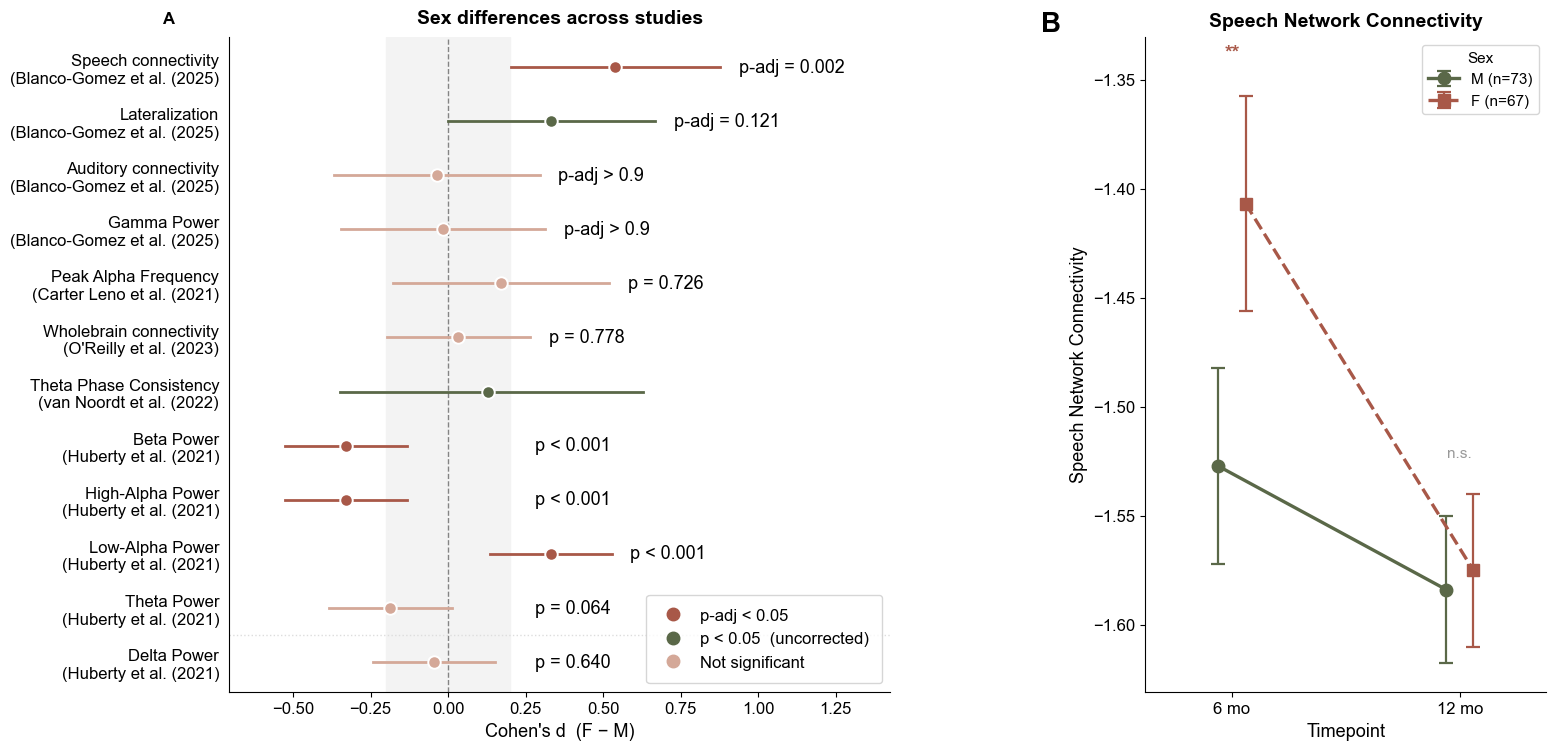

In [24]:
# Palette
M_DARK  = '#5A6848'
M_LIGHT = '#B0BCA0'
F_DARK  = '#A85848'
F_LIGHT = '#D4A898'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':         13,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   20,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

# HELPER FUNCTIONS

def site_residualize(df, col):
    """Return OLS residuals from regressing `col` on site dummies."""
    sub = df[['site', col]].dropna().copy()
    dummies = __import__('pandas').get_dummies(sub['site'], drop_first=True).astype(float)
    X = np.column_stack([np.ones(len(sub)), dummies.values])
    beta = np.linalg.lstsq(X, sub[col].values, rcond=None)[0]
    result = __import__('pandas').Series(np.nan, index=df.index)
    result.loc[sub.index] = sub[col].values - X @ beta
    return result


def cohens_d_ci(f_arr, m_arr):
    """Cohen's d = (F − M) / pooled SD with 95% CI."""
    f = f_arr[~np.isnan(f_arr)]
    m = m_arr[~np.isnan(m_arr)]
    n1, n2 = len(f), len(m)
    pooled = np.sqrt(((n1 - 1) * f.std(ddof=1) ** 2 +
                      (n2 - 1) * m.std(ddof=1) ** 2) / (n1 + n2 - 2))
    d  = (f.mean() - m.mean()) / (pooled if pooled > 0 else 1.0)
    se = np.sqrt((n1 + n2) / (n1 * n2) + d ** 2 / (2 * (n1 + n2 - 2)))
    return d, se, d - 1.96 * se, d + 1.96 * se


# PANEL A: COMPUTE COHEN'S d FOR EACH MEASURE AT 6 MONTHS
#

measures_6mo = {
    'Gamma Power':     'Frontal Gamma Power 6mo',
    'Auditory connectivity':  'Auditory Network 6mo',
    'Speech connectivity':    'Speech Network 6mo',
    'Lateralization':    'Power Lateralization 6mo',
}

# Holmcorrected pvalues from R (Supplementary Table X, Q1 intercept models, IQcorrected)
p_holm_r = {
    'Gamma Power':    1.0000,
    'Auditory connectivity': 1.0000,
    'Speech connectivity':   0.0020,
    'Lateralization':   0.1207,
}
p_raw_r = {
    'Gamma Power':    0.9585,
    'Auditory connectivity': 0.9372,
    'Speech connectivity':   0.0002,
    'Lateralization':   0.0172,
}

df_for_d = plotting_df[['sex', 'site'] + list(measures_6mo.values())].copy()
forest_rows = []

for label, col in measures_6mo.items():
    resid  = site_residualize(df_for_d, col)
    sub    = df_for_d.loc[resid.notna(), ['sex']].copy()
    sub['_r'] = resid
    f_vals = sub.loc[sub['sex'] == 'F', '_r'].values
    m_vals = sub.loc[sub['sex'] == 'M', '_r'].values
    d, se, ci_lo, ci_hi = cohens_d_ci(f_vals, m_vals)
    forest_rows.append({
        'label':      label,
        'd':          d,
        'ci_lo':      ci_lo,
        'ci_hi':      ci_hi,
        'p_holm':     p_holm_r[label],
        'p_raw':      p_raw_r[label],
        'source':     'Blanco-Gomez et al. (2025)',
        'data_avail': True,
    })

# PAF from Carter Leno et al. ttest summary statistics (Stata output)
# F: n=66, mean=7.4875, SD=0.4557 | M: n=61, mean=7.4111, SD=0.4330
paf_nf, paf_mf, paf_sf = 66,  7.4875, 0.4557
paf_nm, paf_mm, paf_sm = 61,  7.4111, 0.4330
paf_pooled = np.sqrt(((paf_nf - 1) * paf_sf ** 2 +
                      (paf_nm - 1) * paf_sm ** 2) / (paf_nf + paf_nm - 2))
paf_d  = (paf_mf - paf_mm) / paf_pooled
paf_se = np.sqrt((paf_nf + paf_nm) / (paf_nf * paf_nm) +
                 paf_d ** 2 / (2 * (paf_nf + paf_nm - 2)))
forest_rows.append({
    'label':      'Peak Alpha Frequency',
    'd':          paf_d,
    'ci_lo':      paf_d - 1.96 * paf_se,
    'ci_hi':      paf_d + 1.96 * paf_se,
    'p_holm':     0.726,    # raw p — not in Q1 Holm family
    'p_raw':      0.726,
    'source':     'Carter Leno et al. (2021)',
    'data_avail': True,
})

# Theta Phase Consistency sexprimary analysis not available
forest_rows.append({
    'label':      'Theta Phase Consistency',
    'd':          0.13,   
    'ci_lo':      -0.35,   
    'ci_hi':      0.63,   
    'p_holm':     np.nan,
    'p_raw':      0.017,  # placeholder for multiple-comparisons correction
    'source':     'van Noordt et al. (2022)',
    'data_avail': True,
})

# Functional Connectivity O'Reilly et al. (2023) MixedLM
 
fc_nobs        = 288
fc_z_m_minus_f = -0.282
fc_p           = 0.778
fc_d           = (-2 * fc_z_m_minus_f) / np.sqrt(fc_nobs)
fc_se_d        = 2 / np.sqrt(fc_nobs)
forest_rows.append({
    'label':      'Wholebrain connectivity',
    'd':          fc_d,
    'ci_lo':      fc_d - 1.96 * fc_se_d,
    'ci_hi':      fc_d + 1.96 * fc_se_d,
    'p_holm':     fc_p,
    'p_raw':      fc_p,
    'source':     "O'Reilly et al. (2023)",
    'data_avail': True,
})

# Huberty et al. (2021) GCM Table 2, InterceptonSex at 6 months

_hub_nf, _hub_nm = 189, 208
_hub_se_d = np.sqrt(1 / _hub_nf + 1 / _hub_nm)

def _hub_row(label, b, p_val):
    """Approximate Cohen's d (F−M) from a GCM intercept-on-sex Wald z."""
    p_safe  = max(p_val, 1e-10)
    z       = _sc.norm.ppf(1 - p_safe / 2)   # |z| from two-tailed p
    sign_fm = np.sign(b)                     # b is M coef; negate for F−M axis
    d       = sign_fm * z * _hub_se_d
    return {
        'label':      label,
        'd':          d,
        'ci_lo':      d - 1.96 * _hub_se_d,
        'ci_hi':      d + 1.96 * _hub_se_d,
        'p_holm':     p_val,
        'p_raw':      p_val,
        'source':     'Huberty et al. (2021)',
        'data_avail': True,
    }

# Compute all Huberty rows first, then sort by |d| descending
_hub_input = [
    ('Delta Power',      -1.12, 0.640),  # ns
    ('Theta Power',      -5.49, 0.064),  # marginal
    ('Low-Alpha Power',  12.31, 0.001),  # reported p < 0.001 → floor at 0.001
    ('High-Alpha Power', -7.97, 0.001),  # reported p < 0.001
    ('Beta Power',       -7.19, 0.001),  # reported p < 0.001
]
_hub_rows = [_hub_row(lbl, b, p) for lbl, b, p in _hub_input]
_hub_rows.sort(key=lambda r: abs(r['d']), reverse=True)
for r in _hub_rows:
    forest_rows.append(r)
_hub_labels_sorted = [r['label'] for r in _hub_rows]


# Plot order: owndata first (sig → marginal → ns), then external
plot_order = [
    'Speech connectivity',
    'Lateralization',
    'Auditory connectivity',
    'Gamma Power',
    'Peak Alpha Frequency',
    'Wholebrain connectivity',
     'Theta Phase Consistency',
    'Beta Power',
    'High-Alpha Power',
    'Low-Alpha Power',
    'Theta Power',
    'Delta Power',
]
fr_dict      = {r['label']: r for r in forest_rows}
ordered_rows = [fr_dict[lbl] for lbl in plot_order]

#
# PANEL B: SPEECH CONNECTIVITY MARGINAL MEANS
#

speech_cols = ['Speech Network 6mo', 'Speech Network 12mo']
tp_x        = [0, 1]
tp_labels   = ['6 mo', '12 mo']
sex_order   = ['M', 'F']
sex_dodge   = {'M': -0.06, 'F': 0.06}
sex_palette = {'M': M_DARK, 'F': F_DARK}
sex_ls      = {'M': '-',    'F': '--'}
sex_marker  = {'M': 'o',    'F': 's'}

speech_emm = {}
for grp in sex_order:
    sub = plotting_df.loc[plotting_df['sex'] == grp, speech_cols]
    speech_emm[grp] = {
        'means': [sub[c].mean()       for c in speech_cols],
        'cis':   [1.96 * sub[c].sem() for c in speech_cols],
    }
n_speech = {
    g: int(plotting_df.loc[plotting_df['sex'] == g, 'Speech Network 6mo'].notna().sum())
    for g in sex_order
}

# BUILD FIGURE
# Height increased to ~0.7 in/row for 12 entries.

fig1, (ax_A, ax_B) = plt.subplots(
    1, 2,
    figsize=(17.0, 8.5),
    gridspec_kw={'width_ratios': [1.65, 1], 'wspace': 0.48},
)

# PANEL A: FOREST PLOT

# Colour encodes significance warm palette consistent with rest of notebook
SIG_COLOR  = F_DARK    # '#A85848'  Holm p < 0.05       brick red
MARG_COLOR = M_DARK    # '#5A6848'  raw p < 0.05 only   muted olive green
NULL_COLOR = F_LIGHT   # '#D4A898'  not significant     light salmon
THETA_COL  = '#AAAAAA' # no effect-size estimate        mid grey

# Shape encodes source (marker, size)
_SOURCE_MARKER = {
    'Blanco-Gomez et al. (2025)':                ('o', 11),
    'Carter Leno et al. (2021)': ('^', 13),
    "O'Reilly et al. (2023)":    ('D', 9),
    'Huberty et al. (2021)':     ('s', 9),
    'van Noordt et al. (2022)':  ('v', 13),
}

def row_color(r):
    """Colour encodes significance level regardless of source."""
    if pd.isna(r['d']):
        return THETA_COL
    if not pd.isna(r['p_holm']) and r['p_holm'] < 0.05:
        return SIG_COLOR
    if not pd.isna(r['p_raw']) and r['p_raw'] < 0.05:
        return MARG_COLOR
    return NULL_COLOR

y_pos = np.arange(len(ordered_rows))  # y=0 at top

# Grey "trivial effect" band
ax_A.axvspan(-0.2, 0.2, color='#F3F3F3', zorder=0)
ax_A.axvline(0, color='#555555', lw=1.0, ls='--', zorder=1, alpha=0.7)

for i, row in enumerate(ordered_rows):
    y   = y_pos[i]
    col = row_color(row)

 # CI bar
    ax_A.plot([row['ci_lo'], row['ci_hi']], [y, y], color=col, lw=2, zorder=4)
 # Point estimate shape encodes source
 #mkr, mkr_sz = _SOURCE_MARKER.get(row['source'], ('P', 9))
    ax_A.plot(row['d'], y, marker='o', color=col,
              markersize=9, zorder=5,
              markeredgecolor='white', markeredgewidth=1.4)

 # pvalue label (right of CI)
    if row['source'] != 'Blanco-Gomez et al. (2025)':
        if pd.isna(row['p_holm']):
            p_lbl = ''
        elif row['p_holm'] <= 0.001:
            p_lbl = 'p < 0.001'
        else:
            p_lbl = f"p = {row['p_holm']:.3f}"
    elif row['p_holm'] < 0.001:
        p_lbl = 'p-adj < 0.001'
    elif row['p_holm'] > 0.999:
        p_lbl = 'p-adj > 0.9'
    else:
        p_lbl = f"p-adj = {row['p_holm']:.3f}"

    ci_hi_safe = row['ci_hi'] if not pd.isna(row['ci_hi']) else 0.0
    x_lbl = max(ci_hi_safe, 0.22) + 0.06
    ax_A.text(x_lbl, y, p_lbl, va='center', ha='left',
              fontsize=13, color='black')

# Dotted separator before the last row (Theta Phase no sex data)
ax_A.axhline(len(ordered_rows) - 1.5, color='#DDDDDD', lw=1.0,
             ls=':', zorder=1)

# Yaxis: measure labels
ax_A.set_yticks(y_pos)
ax_A.set_yticklabels(
    [f"{r['label']}\n({r['source']}" if r['source'] != 'currentstudy' else r['label'] for r in ordered_rows], fontsize=12
)
for tick, row in zip(ax_A.get_yticklabels(), ordered_rows):
    if '*' in row['label']:
        tick.set_color(SIG_COLOR)
        tick.set_fontweight('bold')
    elif not row['data_avail']:
        tick.set_color(THETA_COL)
ax_A.invert_yaxis()
ax_A.tick_params(axis='y', left=False)

# Dynamic xaxis limit
valid_d  = [r for r in ordered_rows if r['data_avail'] and not np.isnan(r['d'])]
xlim_lo  = min(r['ci_lo'] for r in valid_d) - 0.18
xlim_hi  = max(r['ci_hi'] for r in valid_d) + 0.55   # room for p-labels
ax_A.set_xlim(xlim_lo, xlim_hi)

ax_A.set_xlabel("Cohen's d  (F − M)", fontsize=13)
ax_A.set_title('Sex differences across studies', pad=10)

leg_handles = [
    Line2D([0],[0], marker='o', color=SIG_COLOR,  ls='None', ms=9,
           label='p-adj < 0.05'),
    Line2D([0],[0], marker='o', color=MARG_COLOR, ls='None', ms=9,
           label='p < 0.05  (uncorrected)'),
    Line2D([0],[0], marker='o', color=NULL_COLOR, ls='None', ms=9,
           label='Not significant'),
]
ax_A.legend(handles=leg_handles, loc='lower right', fontsize=12,
            frameon=True, facecolor='white', edgecolor='#CCCCCC',
            handlelength=1.6, borderpad=0.8, labelspacing=0.5)

ax_A.text(-0.10, 1.04, 'A', transform=ax_A.transAxes,
          fontsize=12, fontweight='bold', va='top', ha='left')

# PANEL B: SPEECH CONNECTIVITY TRAJECTORY

for grp in sex_order:
    emm   = speech_emm[grp]
    x_plt = [x + sex_dodge[grp] for x in tp_x]
    ax_B.errorbar(
        x_plt, emm['means'], yerr=emm['cis'],
        color=sex_palette[grp], ls=sex_ls[grp],
        marker=sex_marker[grp], ms=9, lw=2.4,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=f"{grp} (n={n_speech[grp]})",
        zorder=4,
    )

# Significance annotations
y_tops_6  = [speech_emm[g]['means'][0] + speech_emm[g]['cis'][0] for g in sex_order]
y_tops_12 = [speech_emm[g]['means'][1] + speech_emm[g]['cis'][1] for g in sex_order]

y_all_tops = y_tops_6 + y_tops_12
y_span = np.nanmax(y_all_tops) - np.nanmin(y_all_tops)
if not np.isfinite(y_span) or y_span <= 0:
    y_lo_tmp, y_hi_tmp = ax_B.get_ylim()
    y_span = max(y_hi_tmp - y_lo_tmp, 1e-6)
y_offset = 0.08 * y_span

y_sig_6 = max(y_tops_6) + y_offset
ax_B.text(tp_x[0], y_sig_6,
          '**', ha='center', va='bottom',
          fontsize=14, color=F_DARK, fontweight='bold')
ax_B.set_xticks(tp_x)
y_sig_12 = max(y_tops_12) + y_offset
ax_B.text(tp_x[1], y_sig_12,
          'n.s.', ha='center', va='bottom',
          fontsize=11, color='#999999')

y_lo_B, y_hi_B = ax_B.get_ylim()
y_top_needed = max(y_hi_B, y_sig_6, y_sig_12) + 0.06 * y_span
ax_B.set_ylim(y_lo_B, y_top_needed)
ax_B.text(-0.26, 1.04, 'B', transform=ax_B.transAxes,
          fontsize=20, fontweight='bold', va='top', ha='left')

ax_B.set_xticks(tp_x)
ax_B.set_xticklabels(tp_labels, fontsize=12)
ax_B.set_xlim(-0.38, 1.38)
ax_B.set_xlabel('Timepoint', fontsize=13)
ax_B.set_ylabel('Speech Network Connectivity', fontsize=13)
ax_B.set_title('Speech Network Connectivity', pad=8)
ax_B.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc',
            fontsize=11, title_fontsize=11, loc='upper right')



# Save dpi=300, bbox_inches='tight', facecolor='white')

plt.tight_layout()
plt.savefig('../../figures/main/Fig1_effect_sizes.tiff')
os.makedirs('../../figures/main/', exist_ok=True)
plt.show()


## **Main Figure #3** Language growth curves

### **Fig.3** Language differences across clusters


In [25]:
## Create wide long format for langauge measures

lang_wide=plotting_df.copy()
cleaned_expres_vars = [var for var in cleaned_language_vars if "expressive" in var.lower() ]
cleaned_receptive_vars = [var for var in cleaned_language_vars if "receptive" in var.lower() ]
expressive_df= lang_wide[["HC Class"] + ["LPA Class"] + ["sex"] + ["outcome"] + ["subject"] + cleaned_expres_vars]
receptive_df= lang_wide[["HC Class"] + ["LPA Class"] + ["sex"] + ["outcome"] +["subject"]+ cleaned_receptive_vars]



# Rename the timepoints
expressive_df = expressive_df.melt(id_vars=["HC Class", "LPA Class","subject",'sex', 'outcome'], var_name="Age", value_name="score")
expressive_df["Age"] = expressive_df["Age"].str.extract("(\d+)").astype(int)
expressive_df["Measure"] = "Expressive"

# Rename the timepoints
receptive_df = receptive_df.melt(id_vars=["HC Class", "LPA Class","subject",'sex','outcome'], var_name="Age", value_name="score")
receptive_df["Age"] = receptive_df["Age"].str.extract("(\d+)").astype(int)
receptive_df["Measure"] = "Receptive"
ages = [6, 12, 18, 24, 36]


In [26]:
# EEG measures at 6 months
plotting_df.columns
# Select only columns at 6 months
eeg_6mo_cols = [col for col in plotting_df.columns if "6mo" in col]
eeg_6mo_df = plotting_df[[ "subject" , "HC Class", "sex"] + eeg_6mo_cols]
eeg_6mo_df.columns

Index(['subject', 'HC Class', 'sex', 'Frontal Gamma Power 6mo', 'DMN 6mo',
       'Attention Network 6mo', 'Visual Network 6mo', 'Auditory Network 6mo',
       'Language Network 6mo', 'Speech Network 6mo',
       'Power Lateralization 6mo'],
      dtype='object')

### Expressive + Receptive language scores HC Classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\230043305.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('HC Class')[radar_features].mean())
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\230043305.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_sizes = eeg_6mo_df.groupby('HC Class')['subject'].nunique()
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\230043305.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default

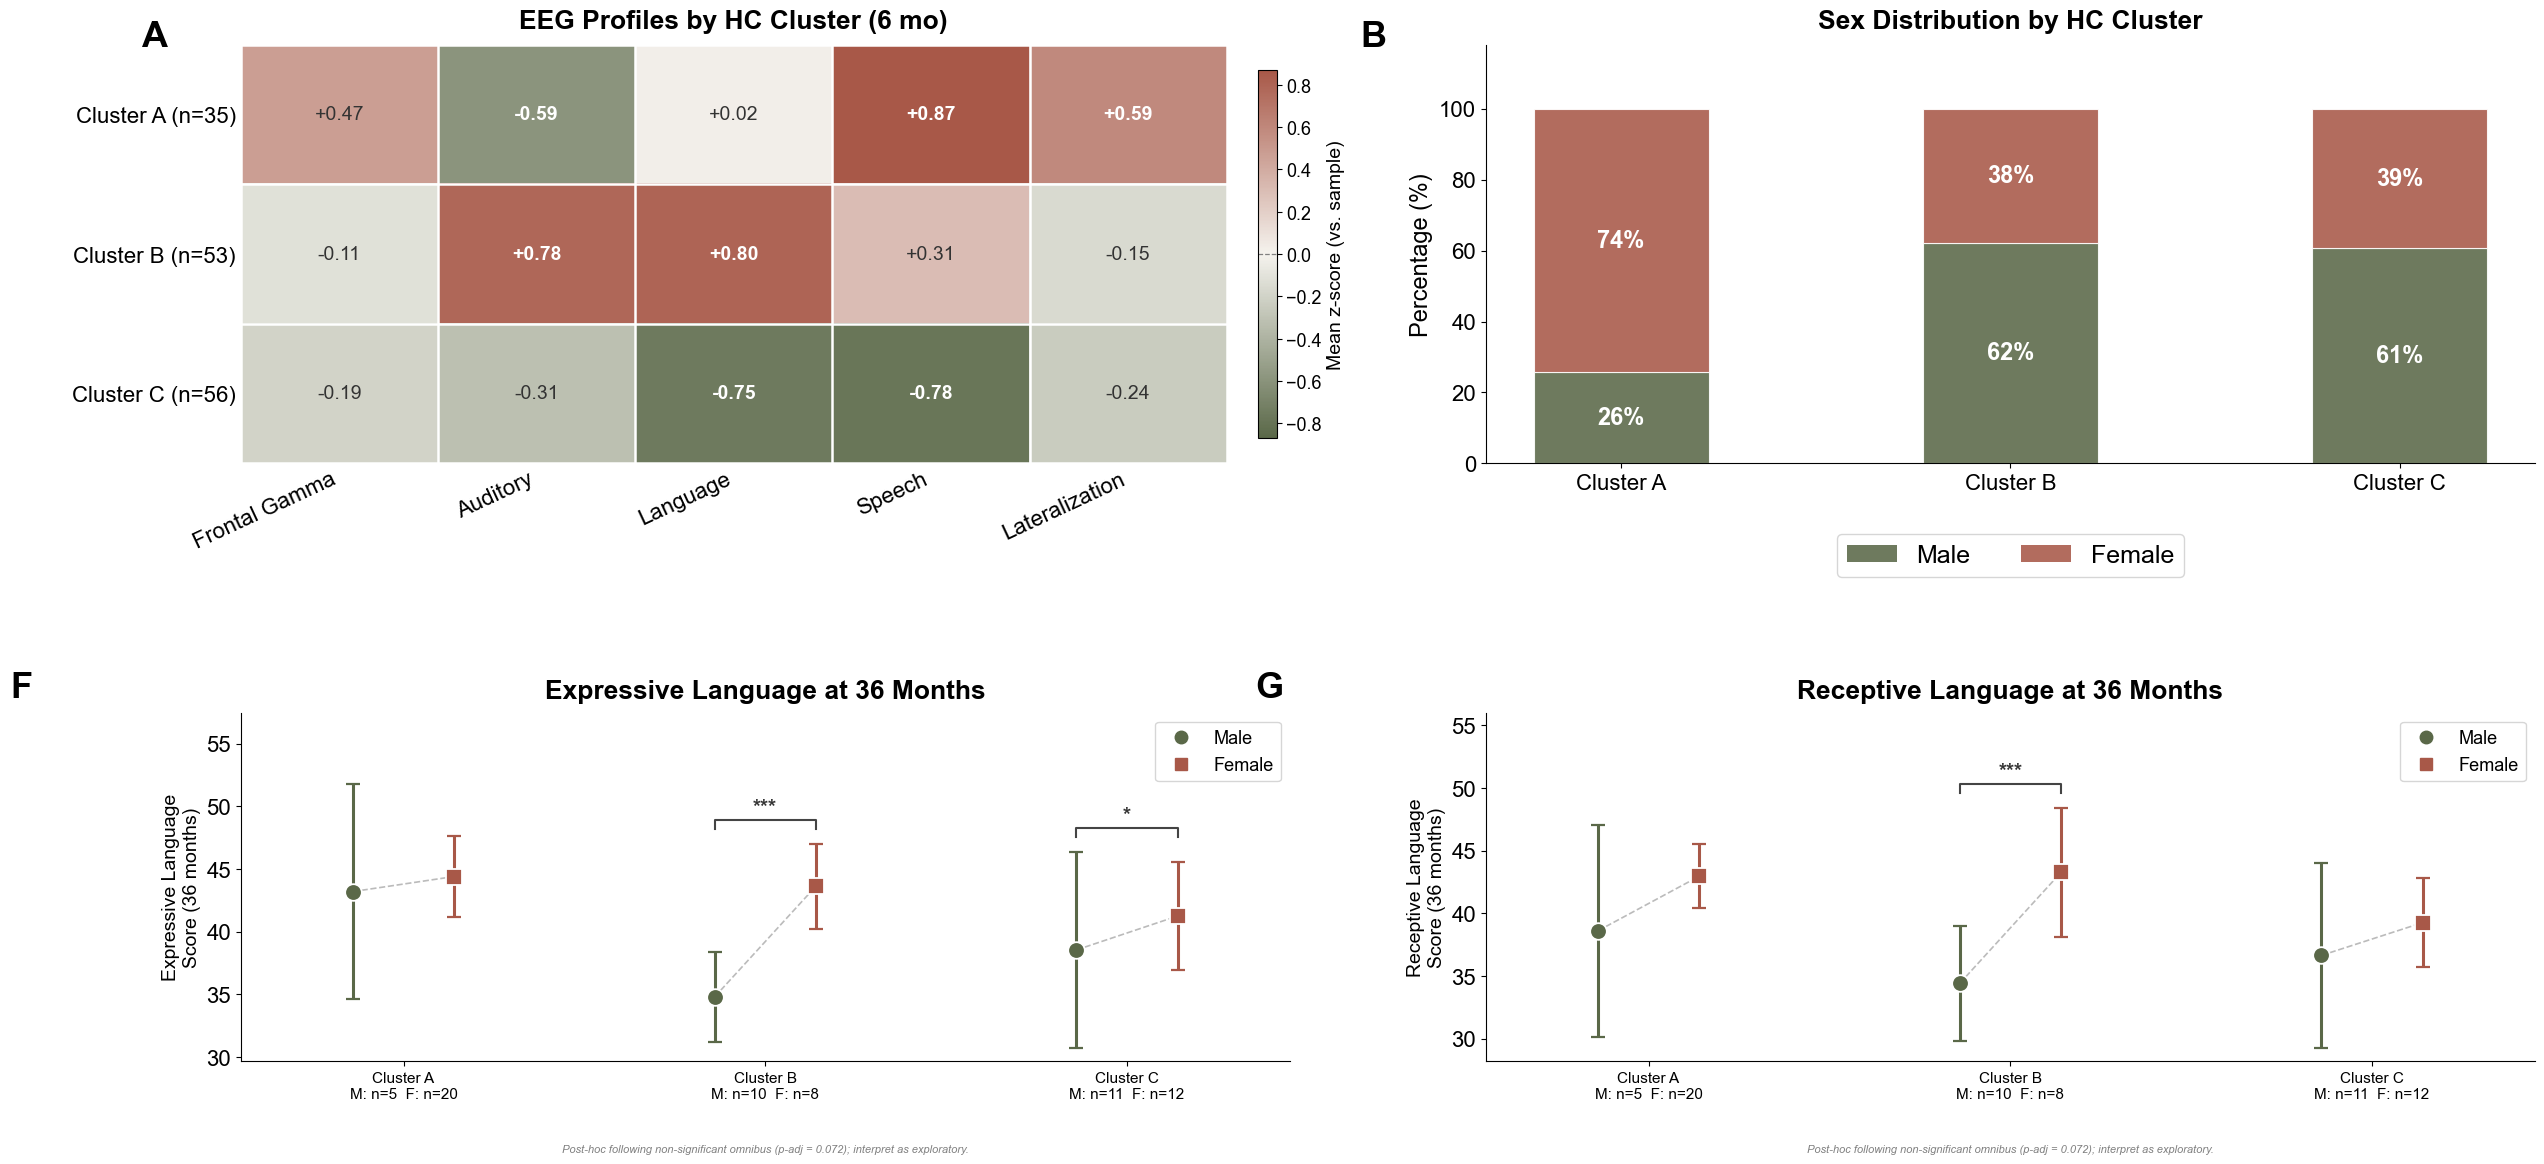

In [27]:
# Palette
M_DARK  = '#5A6848'
M_LIGHT = '#B0BCA0'
F_DARK  = '#A85848'
F_LIGHT = '#D4A898'

hc_class_palette = {'a': '#A85848', 'b': '#942A3E', 'c': '#528352'}
sex_col_palette  = {'M': M_DARK,    'F': F_DARK}
sex_col_ls       = {'M': '-',       'F': '--'}
sex_col_marker   = {'M': 'o',       'F': 's'}

plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        19,
    'axes.titleweight':      'bold',
    'axes.labelsize':        17,
    'xtick.labelsize':       16,
    'ytick.labelsize':       16,
    'legend.fontsize':       15,
    'legend.title_fontsize': 16,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# EEG features for heatmap
radar_features = [
    'Frontal Gamma Power 6mo',
    'Auditory Network 6mo',
    'Language Network 6mo',
    'Speech Network 6mo',
    'Power Lateralization 6mo',
]
radar_labels   = ['Frontal Gamma', 'Auditory', 'Language', 'Speech', 'Lateralization']
hc_class_order = sorted(eeg_6mo_df['HC Class'].dropna().unique())   # ['a', 'b', 'c']
ages           = sorted(expressive_df['Age'].dropna().unique())

# Figure layout: 2 rows × 4 cols
fig_lang2 = plt.figure(figsize=(7.4 * 4, 6.6 * 2))
gs2 = gridspec.GridSpec(
    2, 4,
    figure=fig_lang2,
    hspace=0.65,
    wspace=0.46,
    height_ratios=[1.20, 1.0],
)

ax_hm  = fig_lang2.add_subplot(gs2[0, 0:2])   # Panel A — heatmap
ax_sd  = fig_lang2.add_subplot(gs2[0, 2:4])   # Panel B — sex distribution
ax_g   = fig_lang2.add_subplot(gs2[1, 0:2])   # Panel F — 36-mo expressive
ax_g2  = fig_lang2.add_subplot(gs2[1, 2:4])   # Panel G — 36-mo receptive

# PANEL A EEG profile heatmap
#

eeg_z = eeg_6mo_df.copy()
for feat in radar_features:
    mu, sd  = eeg_z[feat].mean(), eeg_z[feat].std()
    eeg_z[feat] = (eeg_z[feat] - mu) / (sd if sd > 0 else 1.0)

profiles      = (eeg_z.dropna(subset=['HC Class'])
                 .groupby('HC Class')[radar_features].mean())
cluster_sizes = eeg_6mo_df.groupby('HC Class')['subject'].nunique()

cluster_row_labels = [
    f'Cluster {c.upper()} (n={cluster_sizes.get(c, "?")})'
    for c in profiles.index
]
z_mat = profiles.values
vabs  = np.nanmax(np.abs(z_mat))

cmap_div = mpl.colors.LinearSegmentedColormap.from_list(
    'olive_brick', [M_DARK, '#F5F3EE', F_DARK])
norm_div = mpl.colors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)

im = ax_hm.imshow(z_mat, cmap=cmap_div, norm=norm_div,
                  aspect='auto', interpolation='nearest')

for i in range(z_mat.shape[0]):
    for j in range(z_mat.shape[1]):
        zv = z_mat[i, j]
        tc = 'white' if abs(zv) > vabs * 0.55 else '#333333'
        ax_hm.text(j, i, f'{zv:+.2f}', ha='center', va='center',
                   fontsize=14, color=tc,
                   fontweight='bold' if abs(zv) > vabs * 0.55 else 'normal')

ax_hm.set_xticks(range(len(radar_labels)))
ax_hm.set_xticklabels(radar_labels, fontsize=16, rotation=25, ha='right')
ax_hm.set_yticks(range(len(cluster_row_labels)))
ax_hm.set_yticklabels(cluster_row_labels, fontsize=16)
ax_hm.xaxis.set_ticks_position('bottom')
ax_hm.tick_params(length=0)
ax_hm.spines[:].set_visible(False)

for x in np.arange(-0.5, len(radar_labels), 1):
    ax_hm.axvline(x, color='white', lw=1.8)
for y in np.arange(-0.5, len(hc_class_order), 1):
    ax_hm.axhline(y, color='white', lw=1.8)

cbar = fig_lang2.colorbar(im, ax=ax_hm, orientation='vertical',
                           fraction=0.030, pad=0.03, shrink=0.88)
cbar.set_label('Mean z-score (vs. sample)', fontsize=14)
cbar.ax.tick_params(labelsize=13)
cbar.ax.axhline(0, color='gray', lw=0.9, ls='--')

ax_hm.set_title('EEG Profiles by HC Cluster (6 mo)', pad=12)
ax_hm.text(-0.10, 1.06, 'A', transform=ax_hm.transAxes,
           fontsize=26, fontweight='bold', va='top', ha='left')

#
# PANEL B Sex distribution per cluster
#

sex_cts = (eeg_6mo_df.dropna(subset=['HC Class', 'sex'])
           .groupby(['HC Class', 'sex'])['subject']
           .nunique().unstack(fill_value=0))
for s in ['M', 'F']:
    if s not in sex_cts.columns:
        sex_cts[s] = 0
sex_pct = sex_cts.div(sex_cts.sum(axis=1), axis=0) * 100

x_bars = np.arange(len(sex_pct))
bm = ax_sd.bar(x_bars, sex_pct['M'], width=0.45,
               color=M_DARK, alpha=0.88, edgecolor='white', lw=0.8)
bf = ax_sd.bar(x_bars, sex_pct['F'], width=0.45, bottom=sex_pct['M'],
               color=F_DARK, alpha=0.88, edgecolor='white', lw=0.8)

for rect, pct in zip(bm, sex_pct['M']):
    if pct > 6:
        ax_sd.text(rect.get_x() + rect.get_width() / 2, rect.get_height() / 2,
                   f'{pct:.0f}%', ha='center', va='center',
                   fontsize=17, color='white', fontweight='bold')
for rect, bot, pct in zip(bf, sex_pct['M'], sex_pct['F']):
    if pct > 6:
        ax_sd.text(rect.get_x() + rect.get_width() / 2, bot + pct / 2,
                   f'{pct:.0f}%', ha='center', va='center',
                   fontsize=17, color='white', fontweight='bold')

ax_sd.set_xticks(x_bars)
ax_sd.set_xticklabels([f'Cluster {c.upper()}' for c in sex_pct.index], fontsize=16)
ax_sd.set_ylabel('Percentage (%)', fontsize=17)
ax_sd.set_ylim(0, 118)
ax_sd.set_title('Sex Distribution by HC Cluster', pad=12)
ax_sd.legend(
    handles=[mpatches.Patch(facecolor=M_DARK, label='Male',   alpha=0.88),
             mpatches.Patch(facecolor=F_DARK, label='Female', alpha=0.88)],
    frameon=True, facecolor='white', edgecolor='#cccccc',
    fontsize=18, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.14),
)
ax_sd.text(-0.12, 1.06, 'B', transform=ax_sd.transAxes,
           fontsize=26, fontweight='bold', va='top', ha='left')

#
# PANEL F — 36-month expressive language × sex × cluster
#

exp_36 = expressive_df[expressive_df['Age'] == 36].copy()
g_data = (exp_36.dropna(subset=['HC Class', 'sex', 'score'])
          .groupby(['HC Class', 'sex'])['score']
          .agg(['mean', 'sem', 'count'])
          .reset_index())

# Significance from R emmeans (q1_exp, timepoint_c=30, Holm-corrected pairwise):
# [R hc_class mapping: A=cls2, B=cls0, C=cls1]
# Cluster B (hc_class=0): M−F = −6.60, p < 0.001 *** | Cluster C (hc_class=1): M−F = −3.22, p = 0.026 * | Cluster A (hc_class=2): ns
sig_map   = {'a': 'ns', 'b': '***', 'c': '*'}
cls_x_pos = {'a': 0,    'b': 1,     'c': 2}
dodge_g   = {'M': -0.14, 'F': 0.14}

# Draw connecting lines first (below dots)
for cls in hc_class_order:
    sub = g_data[g_data['HC Class'] == cls]
    sub_m = sub[sub['sex'] == 'M']
    sub_f = sub[sub['sex'] == 'F']
    if not sub_m.empty and not sub_f.empty:
        xm = cls_x_pos[cls] + dodge_g['M']
        xf = cls_x_pos[cls] + dodge_g['F']
        ym = sub_m['mean'].values[0]
        yf = sub_f['mean'].values[0]
        ax_g.plot([xm, xf], [ym, yf], color='#BBBBBB', lw=1.2,
                  ls='--', zorder=1)

# Draw dots + CI
for _, row in g_data.iterrows():
    cls = row['HC Class']
    sex = row['sex']
    x   = cls_x_pos[cls] + dodge_g[sex]
    ax_g.plot(x, row['mean'],
              marker=sex_col_marker[sex], color=sex_col_palette[sex],
              ms=12, zorder=4,
              markeredgecolor='white', markeredgewidth=1.3)
    ax_g.errorbar(x, row['mean'], yerr=1.96 * row['sem'],
                  color=sex_col_palette[sex],
                  lw=0, elinewidth=2.2, capsize=5, capthick=1.6, zorder=3)


def _sig_bracket(ax, cls_key, sig_str, g_data_sub):
    """Draw a bracket + significance label above the two dots for a cluster."""
    if sig_str == 'ns':
        return
    sub   = g_data_sub[g_data_sub['HC Class'] == cls_key]
    sub_m = sub[sub['sex'] == 'M']
    sub_f = sub[sub['sex'] == 'F']
    if sub_m.empty or sub_f.empty:
        return
    y_top = max(
        sub_m['mean'].values[0] + 1.96 * sub_m['sem'].values[0],
        sub_f['mean'].values[0] + 1.96 * sub_f['sem'].values[0],
    ) + 1.2
    xm = cls_x_pos[cls_key] + dodge_g['M']
    xf = cls_x_pos[cls_key] + dodge_g['F']
    h  = 0.7
    ax.plot([xm, xm, xf, xf], [y_top, y_top + h, y_top + h, y_top],
            lw=1.5, color='#444444', zorder=5)
    ax.text((xm + xf) / 2, y_top + h + 0.2, sig_str,
            ha='center', va='bottom', fontsize=15,
            color='#333333', fontweight='bold')


for cls, sig in sig_map.items():
    _sig_bracket(ax_g, cls, sig, g_data)

ax_g.set_xticks([0, 1, 2])
_n_labels = []
for _c in ['a', 'b', 'c']:
    _sub = g_data[g_data['HC Class'] == _c]
    _nm = int(_sub[_sub['sex'] == 'M']['count'].values[0]) if not _sub[_sub['sex'] == 'M'].empty else 0
    _nf = int(_sub[_sub['sex'] == 'F']['count'].values[0]) if not _sub[_sub['sex'] == 'F'].empty else 0
    _n_labels.append(f'Cluster {_c.upper()}\nM: n={_nm}  F: n={_nf}')
ax_g.set_xticklabels(_n_labels, fontsize=11)
ax_g.set_xlim(-0.45, 2.45)
ax_g.set_ylabel('Expressive Language\nScore (36 months)', fontsize=14)
ax_g.set_title('Expressive Language at 36 Months', pad=10)
ax_g.text(0.5, -0.26,
          "Post-hoc following non-significant omnibus (p-adj = 0.072); interpret as exploratory.",
          transform=ax_g.transAxes, ha='center', fontsize=8, style='italic', color='gray')

# Extend ylim for brackets
y_lo_g, y_hi_g = ax_g.get_ylim()
ax_g.set_ylim(y_lo_g, y_hi_g + (y_hi_g - y_lo_g) * 0.20)

ax_g.legend(
    handles=[
        Line2D([0],[0], marker='o', color=M_DARK, ls='None', ms=9, label='Male'),
        Line2D([0],[0], marker='s', color=F_DARK, ls='None', ms=9, label='Female'),
    ],
    frameon=True, facecolor='white', edgecolor='#cccccc',
    fontsize=13, loc='upper right',
)
ax_g.text(-0.22, 1.12, 'F', transform=ax_g.transAxes,
          fontsize=26, fontweight='bold', va='top', ha='left')

#
# PANEL G — 36-month receptive language × sex × cluster
#

rec_36 = receptive_df[receptive_df['Age'] == 36].copy()
g2_data = (rec_36.dropna(subset=['HC Class', 'sex', 'score'])
           .groupby(['HC Class', 'sex'])['score']
           .agg(['mean', 'sem', 'count'])
           .reset_index())

# Significance from R emmeans (q3_rec, timepoint_c=30, Holm-corrected pairwise):
# [R hc_class mapping: A=cls2, B=cls0, C=cls1]
# Cluster B (hc_class=0): M−F = −6.35, p < 0.001 *** | Cluster C (hc_class=1): ns | Cluster A (hc_class=2): ns
sig_map_rec = {'a': 'ns', 'b': '***', 'c': 'ns'}

# Draw connecting lines first (below dots)
for cls in hc_class_order:
    sub = g2_data[g2_data['HC Class'] == cls]
    sub_m = sub[sub['sex'] == 'M']
    sub_f = sub[sub['sex'] == 'F']
    if not sub_m.empty and not sub_f.empty:
        xm = cls_x_pos[cls] + dodge_g['M']
        xf = cls_x_pos[cls] + dodge_g['F']
        ym = sub_m['mean'].values[0]
        yf = sub_f['mean'].values[0]
        ax_g2.plot([xm, xf], [ym, yf], color='#BBBBBB', lw=1.2,
                   ls='--', zorder=1)

# Draw dots + CI
for _, row in g2_data.iterrows():
    cls = row['HC Class']
    sex = row['sex']
    x   = cls_x_pos[cls] + dodge_g[sex]
    ax_g2.plot(x, row['mean'],
               marker=sex_col_marker[sex], color=sex_col_palette[sex],
               ms=12, zorder=4,
               markeredgecolor='white', markeredgewidth=1.3)
    ax_g2.errorbar(x, row['mean'], yerr=1.96 * row['sem'],
                   color=sex_col_palette[sex],
                   lw=0, elinewidth=2.2, capsize=5, capthick=1.6, zorder=3)

for cls, sig in sig_map_rec.items():
    _sig_bracket(ax_g2, cls, sig, g2_data)

ax_g2.set_xticks([0, 1, 2])
_n2_labels = []
for _c in ['a', 'b', 'c']:
    _sub2 = g2_data[g2_data['HC Class'] == _c]
    _nm2 = int(_sub2[_sub2['sex'] == 'M']['count'].values[0]) if not _sub2[_sub2['sex'] == 'M'].empty else 0
    _nf2 = int(_sub2[_sub2['sex'] == 'F']['count'].values[0]) if not _sub2[_sub2['sex'] == 'F'].empty else 0
    _n2_labels.append(f'Cluster {_c.upper()}\nM: n={_nm2}  F: n={_nf2}')
ax_g2.set_xticklabels(_n2_labels, fontsize=11)
ax_g2.set_xlim(-0.45, 2.45)
ax_g2.set_ylabel('Receptive Language\nScore (36 months)', fontsize=14)
ax_g2.set_title('Receptive Language at 36 Months', pad=10)
ax_g2.text(0.5, -0.26,
           "Post-hoc following non-significant omnibus (p-adj = 0.072); interpret as exploratory.",
           transform=ax_g2.transAxes, ha='center', fontsize=8, style='italic', color='gray')

y_lo_g2, y_hi_g2 = ax_g2.get_ylim()
ax_g2.set_ylim(y_lo_g2, y_hi_g2 + (y_hi_g2 - y_lo_g2) * 0.20)

ax_g2.legend(
    handles=[
        Line2D([0],[0], marker='o', color=M_DARK, ls='None', ms=9, label='Male'),
        Line2D([0],[0], marker='s', color=F_DARK, ls='None', ms=9, label='Female'),
    ],
    frameon=True, facecolor='white', edgecolor='#cccccc',
    fontsize=13, loc='upper right',
)
ax_g2.text(-0.22, 1.12, 'G', transform=ax_g2.transAxes,
           fontsize=26, fontweight='bold', va='top', ha='left')


# Save
plt.tight_layout()
os.makedirs('../../figures/main/', exist_ok=True)
plt.savefig('../../figures/main/Fig2_language_neurosubtypes_sex.jpeg',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Supplemmentary Figures

### **Supplementary S1** EEG x Likelihood

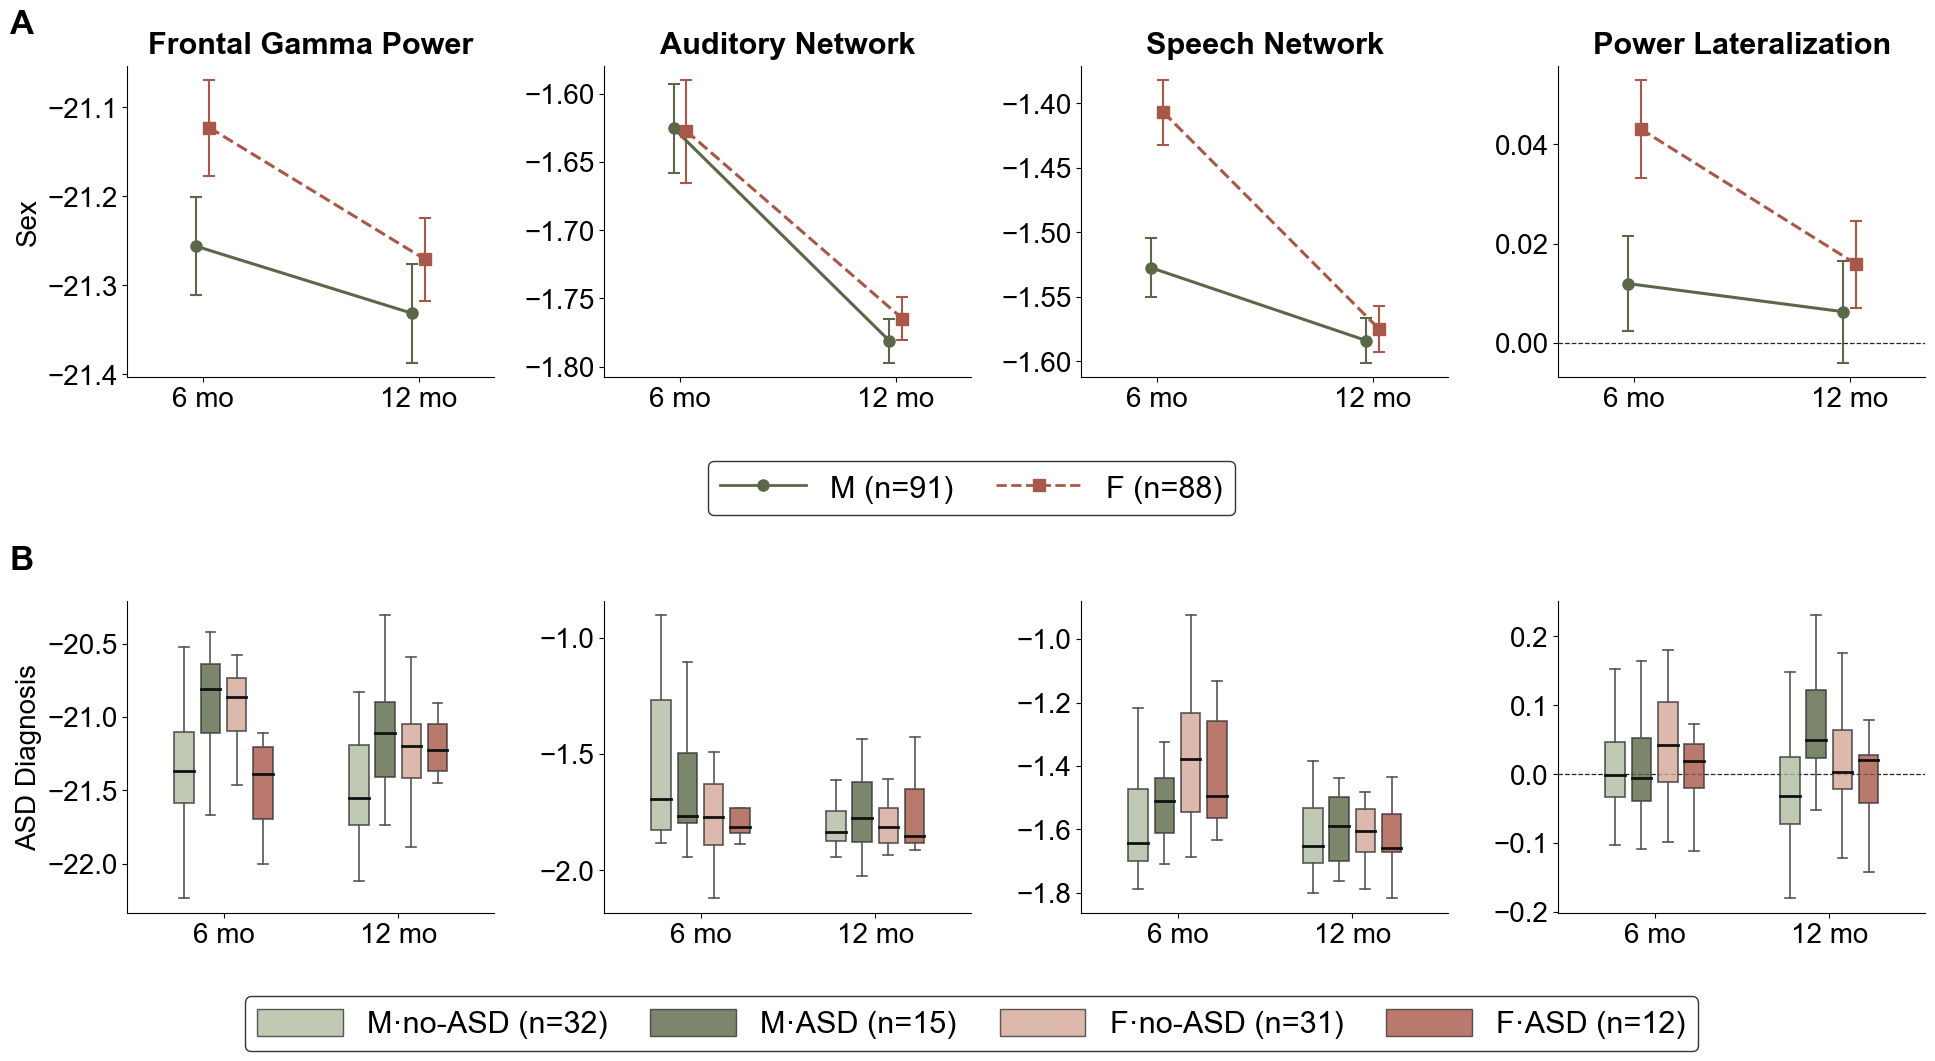

In [28]:
# Palettes Muted Olive & Faded Brick
M_DARK  = '#5A6848'
M_LIGHT = '#B0BCA0'
F_DARK  = '#A85848'
F_LIGHT = '#D4A898'

# Row 1 Sex
sex_palette = {'M': M_DARK, 'F': F_DARK}
sex_ls      = {'M': '-',    'F': '--'}
sex_marker  = {'M': 'o',    'F': 's'}
sex_order   = ['M', 'F']
sex_dodge = {'M': -0.03, 'F': 0.03}

# Row 2 ASD Diagnosis
dx_palette  = {'M·no-ASD': M_LIGHT, 'M·ASD': M_DARK, 'F·no-ASD': F_LIGHT, 'F·ASD': F_DARK}
dx_ls       = {'M·no-ASD': '-',  'M·ASD': '-',  'F·no-ASD': '--', 'F·ASD': '--'}
dx_marker   = {'M·no-ASD': 'o',  'M·ASD': '^',  'F·no-ASD': 's',  'F·ASD': 'D'}
dx_order    = ['M·no-ASD', 'M·ASD', 'F·no-ASD', 'F·ASD']

# Metrics

metrics = {
    'Frontal Gamma Power':  ['Frontal Gamma Power 6mo',  'Frontal Gamma Power 12mo'],
    'Auditory Network':     ['Auditory Network 6mo',     'Auditory Network 12mo'],
    'Speech Network':       ['Speech Network 6mo',       'Speech Network 12mo'],
    'Power Lateralization': ['Power Lateralization 6mo', 'Power Lateralization 12mo'],
}
metric_names = list(metrics.keys())
x_pos     = [0, 1]
tp_labels = ['6 mo', '12 mo']

# rcParams

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size': 20, 'axes.titlesize': 22, 'axes.titleweight': 'bold',
    'axes.labelsize': 20, 'xtick.labelsize': 20, 'ytick.labelsize': 20,
    'legend.fontsize': 16, 'legend.title_fontsize': 16,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

# Prebuild group columns

plot_dx = plotting_df[plotting_df['group_type'] == 'ELA'].dropna(subset=['sex', 'outcome']).copy()
plot_dx['sex_dx'] = plot_dx['sex'] + '·' + plot_dx['outcome'].str.replace('asd', 'ASD', case=False)
plot_dx['sex_dx'] = pd.Categorical(plot_dx['sex_dx'],
                                    categories=dx_order, ordered=True)

# Precompute sample sizes ``

n_sex = {g: int(plotting_df[plotting_df['sex'] == g].shape[0])
          for g in sex_order}
n_dx  = {g: int(plot_dx[plot_dx['sex_dx'] == g].shape[0])
          for g in dx_order}

# Accumulators for perrow legend handles
row_handles = [[], []]

# Figure

fig, axs = plt.subplots(2, 4, figsize=(5.8 * 4, 5.5 * 2),
                         gridspec_kw={'hspace': 0.72, 'wspace': 0.30})

for col_idx, metric in enumerate(metric_names):
    cols   = metrics[metric]
    is_lat = (metric == 'Power Lateralization')

    def zero_line(ax):
        if is_lat:
            ax.axhline(0, color="#252525", linewidth=0.9, linestyle='--', zorder=-1)

 # ROW 0 Sex
    ax = axs[0, col_idx]
    for grp in sex_order:
        sub    = plotting_df[plotting_df['sex'] == grp]
        means  = [sub[c].mean() for c in cols]
        sems   = [sub[c].sem()  for c in cols]
        x_plot = [x + sex_dodge[grp] for x in x_pos]
        ax.errorbar(x_plot, means, yerr=sems,
                    color=sex_palette[grp], linestyle=sex_ls[grp],
                    marker=sex_marker[grp], markersize=8, linewidth=2.2,
                    capsize=4, capthick=1.5, elinewidth=1.5)
        if col_idx == 0:
            row_handles[0].append(
                Line2D([0],[0], color=sex_palette[grp], linestyle=sex_ls[grp],
                       marker=sex_marker[grp], markersize=8, linewidth=2,
                       label=f'{grp} (n={n_sex[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.35, 1.35)
    ax.set_title(metric, pad=9)
    ax.set_ylabel('Sex' if col_idx == 0 else '')

 # ROW 1 ASD Diagnosis (ELA only) BOXPLOTS
    ax = axs[1, col_idx]
    total_width = 0.60
    box_w   = total_width / len(dx_order)
    offsets = np.linspace(-total_width/2 + box_w/2, total_width/2 - box_w/2, len(dx_order))

    for i, grp in enumerate(dx_order):
        sub = plot_dx[plot_dx['sex_dx'] == grp]
        for tp_idx, c in enumerate(cols):
            data     = sub[c].dropna().values
            x_center = x_pos[tp_idx] + offsets[i]
            ax.boxplot(
                data,
                positions=[x_center],
                widths=box_w * 0.75,
                patch_artist=True,
                notch=False,
                showfliers=False,
                boxprops=dict(facecolor=dx_palette[grp], alpha=0.80,
                              linewidth=1.2, edgecolor='#333333'),
                medianprops=dict(color='#111111', linewidth=2.0),
                whiskerprops=dict(color='#555555', linewidth=1.2),
                capprops=dict(color='#555555', linewidth=1.2),
            )
        if col_idx == 0:
            row_handles[1].append(
                mpatches.Patch(facecolor=dx_palette[grp], edgecolor='#333333',
                               alpha=0.80, label=f'{grp} (n={n_dx[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.55, 1.55)
    ax.set_ylabel('ASD Diagnosis' if col_idx == 0 else '')


# Panel letters

for row_idx, letter in enumerate(['A', 'B']):
    axs[row_idx, 0].text(
        -0.32, 1.18, letter,
        transform=axs[row_idx, 0].transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left',
        fontfamily='sans-serif',
    )

# Horizontal legends one per row, centred below

for row_idx, handles in enumerate(row_handles):
    axs[row_idx, 1].legend(
        handles=handles, title=None,
        loc='upper center',
        bbox_to_anchor=(1.0, -0.22),
        ncol=len(handles),
        frameon=True, facecolor='white', edgecolor='black',
        fontsize=22,
        handlelength=2.8, handleheight=1.0,
        columnspacing=1.4,
    )

# Save

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S1_Sex_differences_likelihood_diagnosis.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### **Supplementary S2** EEG diatributions for Sex x Likelihood

C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\3420975709.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\3420975709.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\3420975709.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\3420975709.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

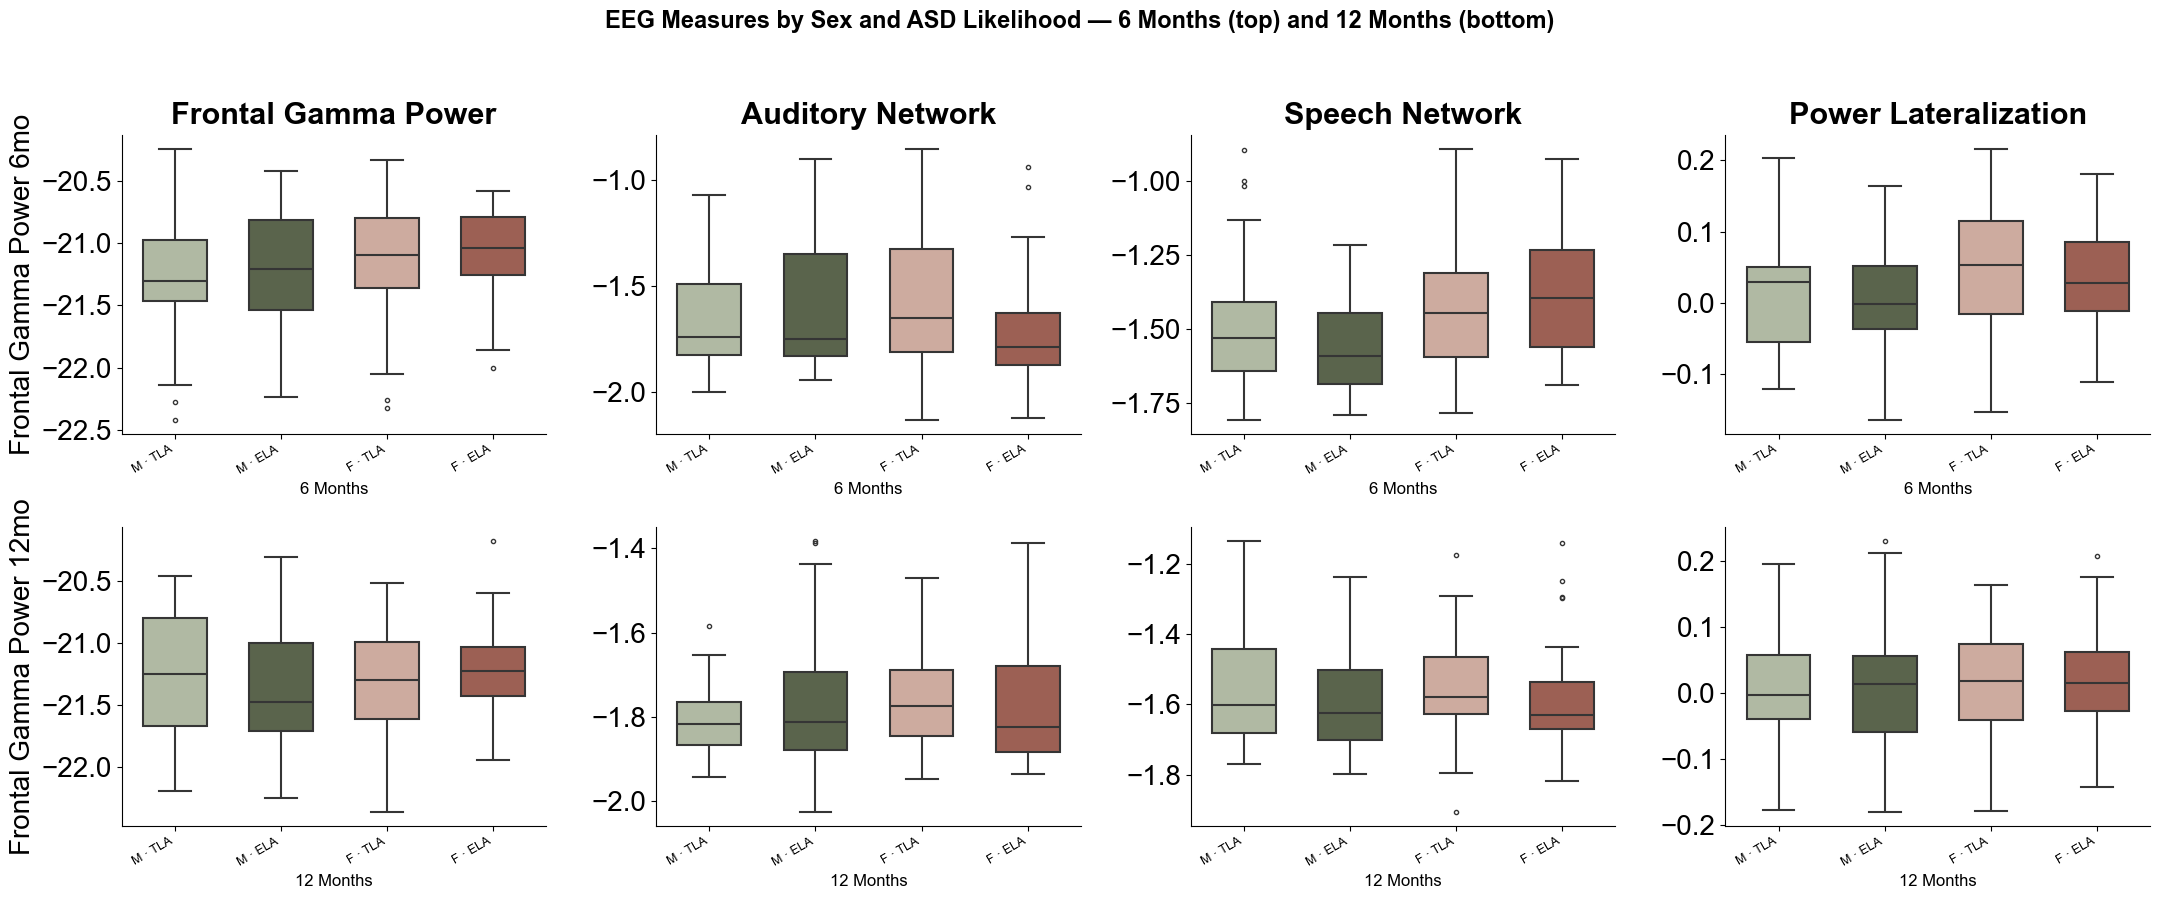

In [29]:

# Fill colours matches M_LIGHT/M_DARK/F_LIGHT/F_DARK from main palette
group_palette = {
    'M · TLA': M_LIGHT,   # '#B0BCA0'  Pale Sage
    'M · ELA': M_DARK,    # '#5A6848'  Muted Olive
    'F · TLA': F_LIGHT,   # '#D4A898'  Pale Terracotta
    'F · ELA': F_DARK,    # '#A85848'  Faded Brick
}

group_order = ['M · TLA', 'M · ELA', 'F · TLA', 'F · ELA']

plot2 = plotting_df.dropna(subset=['sex', 'group_type']).copy()
plot2['sex_group'] = plot2['sex'] + ' · ' + plot2['group_type']
plot2['sex_group'] = pd.Categorical(plot2['sex_group'], categories=group_order, ordered=True)

fig2, axs2 = plt.subplots(2, 4, figsize=(5.5 * 4, 4.5 * 2))
focal_metrics_hist = [
    ('Frontal Gamma Power', 'Frontal Gamma Power 6mo', 'Frontal Gamma Power 12mo'),
    ('Auditory Network',    'Auditory Network 6mo',    'Auditory Network 12mo'),
    ('Speech Network',      'Speech Network 6mo',      'Speech Network 12mo'),
    ('Power Lateralization','Power Lateralization 6mo', 'Power Lateralization 12mo'),
]

for col_idx, (metric_name, col_6, col_12) in enumerate(focal_metrics_hist):
    for row_idx, (col, tp_label) in enumerate([(col_6, '6 Months'), (col_12, '12 Months')]):
        ax = axs2[row_idx, col_idx]
        sub = plot2.dropna(subset=[col]) if col in plot2.columns else None
        if sub is None or col not in plot2.columns:
            ax.set_visible(False)
            continue

        sns.boxplot(
            data=sub, x='sex_group', y=col,
            order=group_order,
            palette=group_palette,
            width=0.6,
            linewidth=1.5,
            fliersize=3,
            ax=ax,
        )

        if row_idx == 0:
            ax.set_title(metric_name, pad=8)
        ax.set_xlabel(tp_label, fontsize=12)
        ax.set_ylabel(col if col_idx == 0 else '')
        ax.tick_params(axis='x', labelrotation=30)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')
            lbl.set_fontsize(9)

fig2.suptitle(
    'EEG Measures by Sex and ASD Likelihood — 6 Months (top) and 12 Months (bottom)',
    fontsize=17, fontweight='bold', y=1.01
)
plt.tight_layout()

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S2_eeg_focal_sex_x_group_boxplots.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S3** Receptive language scores HC Classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\3048589686.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


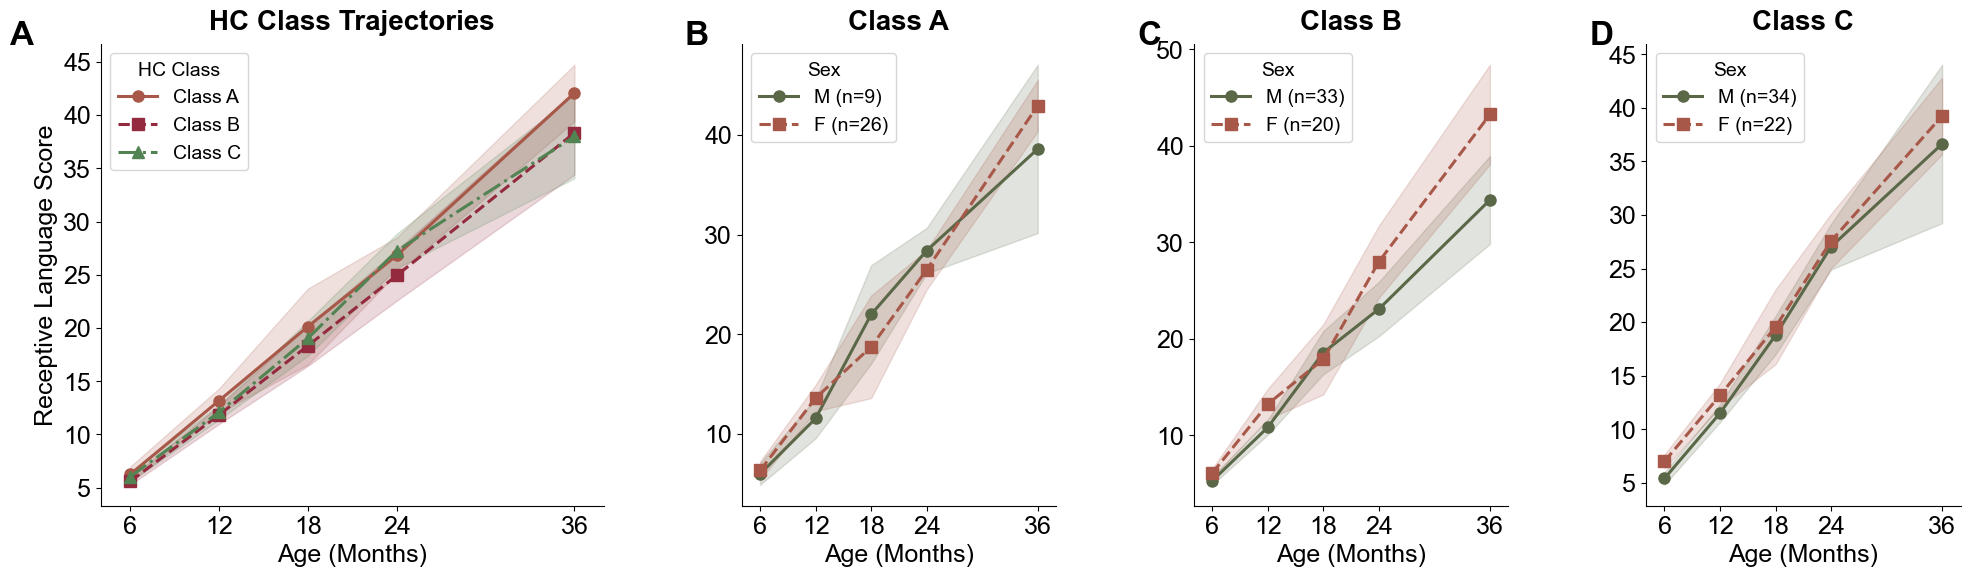

In [30]:
# Expressive Language: HC Class trajectories + sex within each class


plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        20,
    'axes.titleweight':      'bold',
    'axes.labelsize':        18,
    'xtick.labelsize':       18,
    'ytick.labelsize':       18,
    'legend.fontsize':       14,
    'legend.title_fontsize': 14,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# Palettes
# HC class colours warm neutrals distinct from the M/F sex palette
hc_class_palette = {
    'a': "#A85848",   # muted amber
    'c': "#528352",   # muted sage green
    'b': "#942A3E",   # muted maroon

}
hc_class_ls     = {'a': '-',  'b': '--', 'c': '-.'}
hc_class_marker = {'a': 'o',  'b': 's',  'c': '^'}
hc_class_order  = sorted(receptive_df['HC Class'].dropna().unique())

# Sex colours reuse M_DARK / F_DARK from main palette
sex_col_palette = {'M': M_DARK,  'F': F_DARK}
sex_col_ls      = {'M': '-',     'F': '--'}
sex_col_marker  = {'M': 'o',     'F': 's'}

# Figure 1 × 4 with Panel A ~1.6× wider than B/C/D
fig_lang, axs_lang = plt.subplots(
    1, 4,
    figsize=(6.0 * 4, 6.0),
    gridspec_kw={'width_ratios': [1.6, 1, 1, 1],
                 'wspace': 0.38},
)

panel_letters = ['A', 'B', 'C', 'D']

# Panel A: HC class overview (both sexes pooled)
ax = axs_lang[0]
for cls in hc_class_order:
    sub = receptive_df[receptive_df['HC Class'] == cls]
    grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
    grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
    grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
    ax.plot(grouped['Age'], grouped['mean'],
            color=hc_class_palette[cls], linestyle=hc_class_ls[cls],
            marker=hc_class_marker[cls], markersize=8, linewidth=2.2,
            label=f'Class {cls.upper()}')
    ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                    color=hc_class_palette[cls], alpha=0.18)

ax.set_title('HC Class Trajectories', pad=10)
ax.set_xlabel('Age (Months)')
ax.set_ylabel('Receptive Language Score')
ax.set_xticks(ages)
ax.set_xlim(min(ages) - 2, max(ages) + 2)
ax.legend(title='HC Class', frameon=True, facecolor='white', edgecolor='#cccccc')

# Panel A letter
ax.text(-0.18, 1.05, 'A',
        transform=ax.transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left')

# Panels BD: M vs F within each HC class
for panel_idx, cls in enumerate(hc_class_order):
    ax = axs_lang[panel_idx + 1]
    sub_cls = receptive_df[receptive_df['HC Class'] == cls].dropna(subset=['sex'])

    for sex in ['M', 'F']:
        sub = sub_cls[sub_cls['sex'] == sex]
        if sub.empty:
            continue
        grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
        grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
        grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
        n_sub = sub['subject'].nunique() if 'subject' in sub.columns else len(sub)
        ax.plot(grouped['Age'], grouped['mean'],
                color=sex_col_palette[sex], linestyle=sex_col_ls[sex],
                marker=sex_col_marker[sex], markersize=8, linewidth=2.2,
                label=f'{sex} (n={n_sub})')
        ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                        color=sex_col_palette[sex], alpha=0.18)

    ax.set_title(f'Class {cls.upper()}', pad=10)
    ax.set_xlabel('Age (Months)')
    ax.set_ylabel('')
    ax.set_xticks(ages)
    ax.set_xlim(min(ages) - 2, max(ages) + 2)
    ax.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc')

 # Panel letters B, C, D
    ax.text(-0.18, 1.05, panel_letters[panel_idx + 1],
            transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left')



# (Plotting of the combined expressive + receptive figure is handled in the next cell.)
plt.tight_layout()
os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S3_receptive_language_HC_sex_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S4** Expressive Lanuage scores for classes

C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\402235511.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


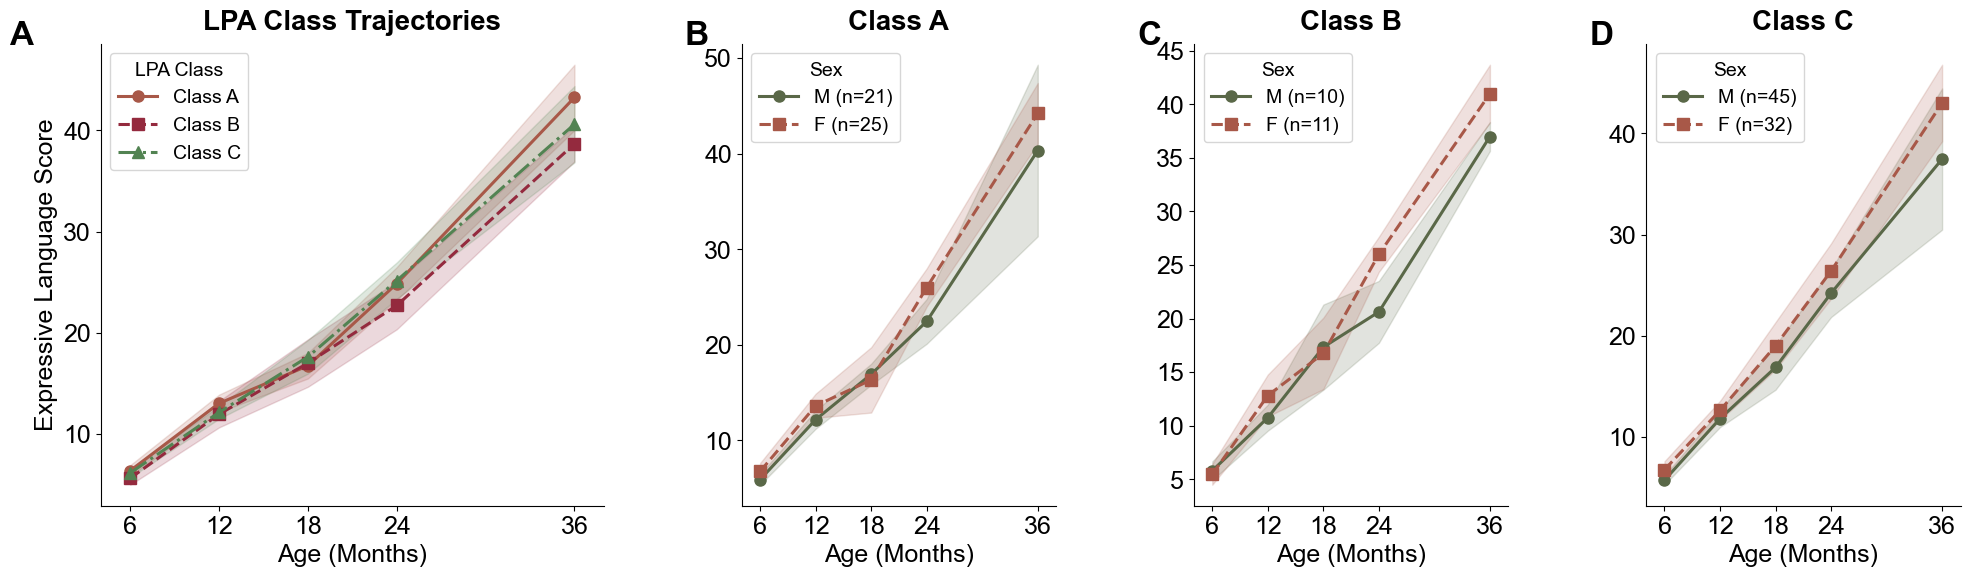

In [31]:
plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':             18,
    'axes.titlesize':        20,
    'axes.titleweight':      'bold',
    'axes.labelsize':        18,
    'xtick.labelsize':       18,
    'ytick.labelsize':       18,
    'legend.fontsize':       14,
    'legend.title_fontsize': 14,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        'white',
})

# Palettes
# HC class colours warm neutrals distinct from the M/F sex palette
hc_class_palette = {
    'A': "#A85848",   # muted amber
    'C': "#528352",   # muted sage green
    'B': "#942A3E",   # muted maroon

}
hc_class_ls     = {'A': '-',  'B': '--', 'C': '-.'}
hc_class_marker = {'A': 'o',  'B': 's',  'C': '^'}
hc_class_order  = sorted(expressive_df['LPA Class'].dropna().unique())

# Sex colours reuse M_DARK / F_DARK from main palette
sex_col_palette = {'M': M_DARK,  'F': F_DARK}
sex_col_ls      = {'M': '-',     'F': '--'}
sex_col_marker  = {'M': 'o',     'F': 's'}

# Figure 1 × 4 with Panel A ~1.6× wider than B/C/D
fig_lang, axs_lang = plt.subplots(
    1, 4,
    figsize=(6.0 * 4, 6.0),
    gridspec_kw={'width_ratios': [1.6, 1, 1, 1],
                 'wspace': 0.38},
)

panel_letters = ['A', 'B', 'C', 'D']

# Panel A: LPA class overview (both sexes pooled)
ax = axs_lang[0]
for cls in hc_class_order:
    sub = expressive_df[expressive_df['LPA Class'] == cls]
    grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
    grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
    grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
    ax.plot(grouped['Age'], grouped['mean'],
            color=hc_class_palette[cls], linestyle=hc_class_ls[cls],
            marker=hc_class_marker[cls], markersize=8, linewidth=2.2,
            label=f'Class {cls.upper()}')
    ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                    color=hc_class_palette[cls], alpha=0.18)

ax.set_title('LPA Class Trajectories', pad=10)
ax.set_xlabel('Age (Months)')
ax.set_ylabel('Expressive Language Score')
ax.set_xticks(ages)
ax.set_xlim(min(ages) - 2, max(ages) + 2)
ax.legend(title='LPA Class', frameon=True, facecolor='white', edgecolor='#cccccc')

# Panel A letter
ax.text(-0.18, 1.05, 'A',
        transform=ax.transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left')

# Panels BD: M vs F within each LPA class
for panel_idx, cls in enumerate(hc_class_order):
    ax = axs_lang[panel_idx + 1]
    sub_cls = expressive_df[expressive_df['LPA Class'] == cls].dropna(subset=['sex'])

    for sex in ['M', 'F']:
        sub = sub_cls[sub_cls['sex'] == sex]
        if sub.empty:
            continue
        grouped = sub.groupby('Age')['score'].agg(['mean', 'sem']).reset_index()
        grouped['ci_lo'] = grouped['mean'] - 1.96 * grouped['sem']
        grouped['ci_hi'] = grouped['mean'] + 1.96 * grouped['sem']
        n_sub = sub['subject'].nunique() if 'subject' in sub.columns else len(sub)
        ax.plot(grouped['Age'], grouped['mean'],
                color=sex_col_palette[sex], linestyle=sex_col_ls[sex],
                marker=sex_col_marker[sex], markersize=8, linewidth=2.2,
                label=f'{sex} (n={n_sub})')
        ax.fill_between(grouped['Age'], grouped['ci_lo'], grouped['ci_hi'],
                        color=sex_col_palette[sex], alpha=0.18)

    ax.set_title(f'Class {cls.upper()}', pad=10)
    ax.set_xlabel('Age (Months)')
    ax.set_ylabel('')
    ax.set_xticks(ages)
    ax.set_xlim(min(ages) - 2, max(ages) + 2)
    ax.legend(title='Sex', frameon=True, facecolor='white', edgecolor='#cccccc')

 # Panel letters B, C, D
    ax.text(-0.18, 1.05, panel_letters[panel_idx + 1],
            transform=ax.transAxes,
            fontsize=24, fontweight='bold', va='top', ha='left')



plt.tight_layout()
os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S4_expressive_language_LPA_sex_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S5** EEG Feature Distribution by sex


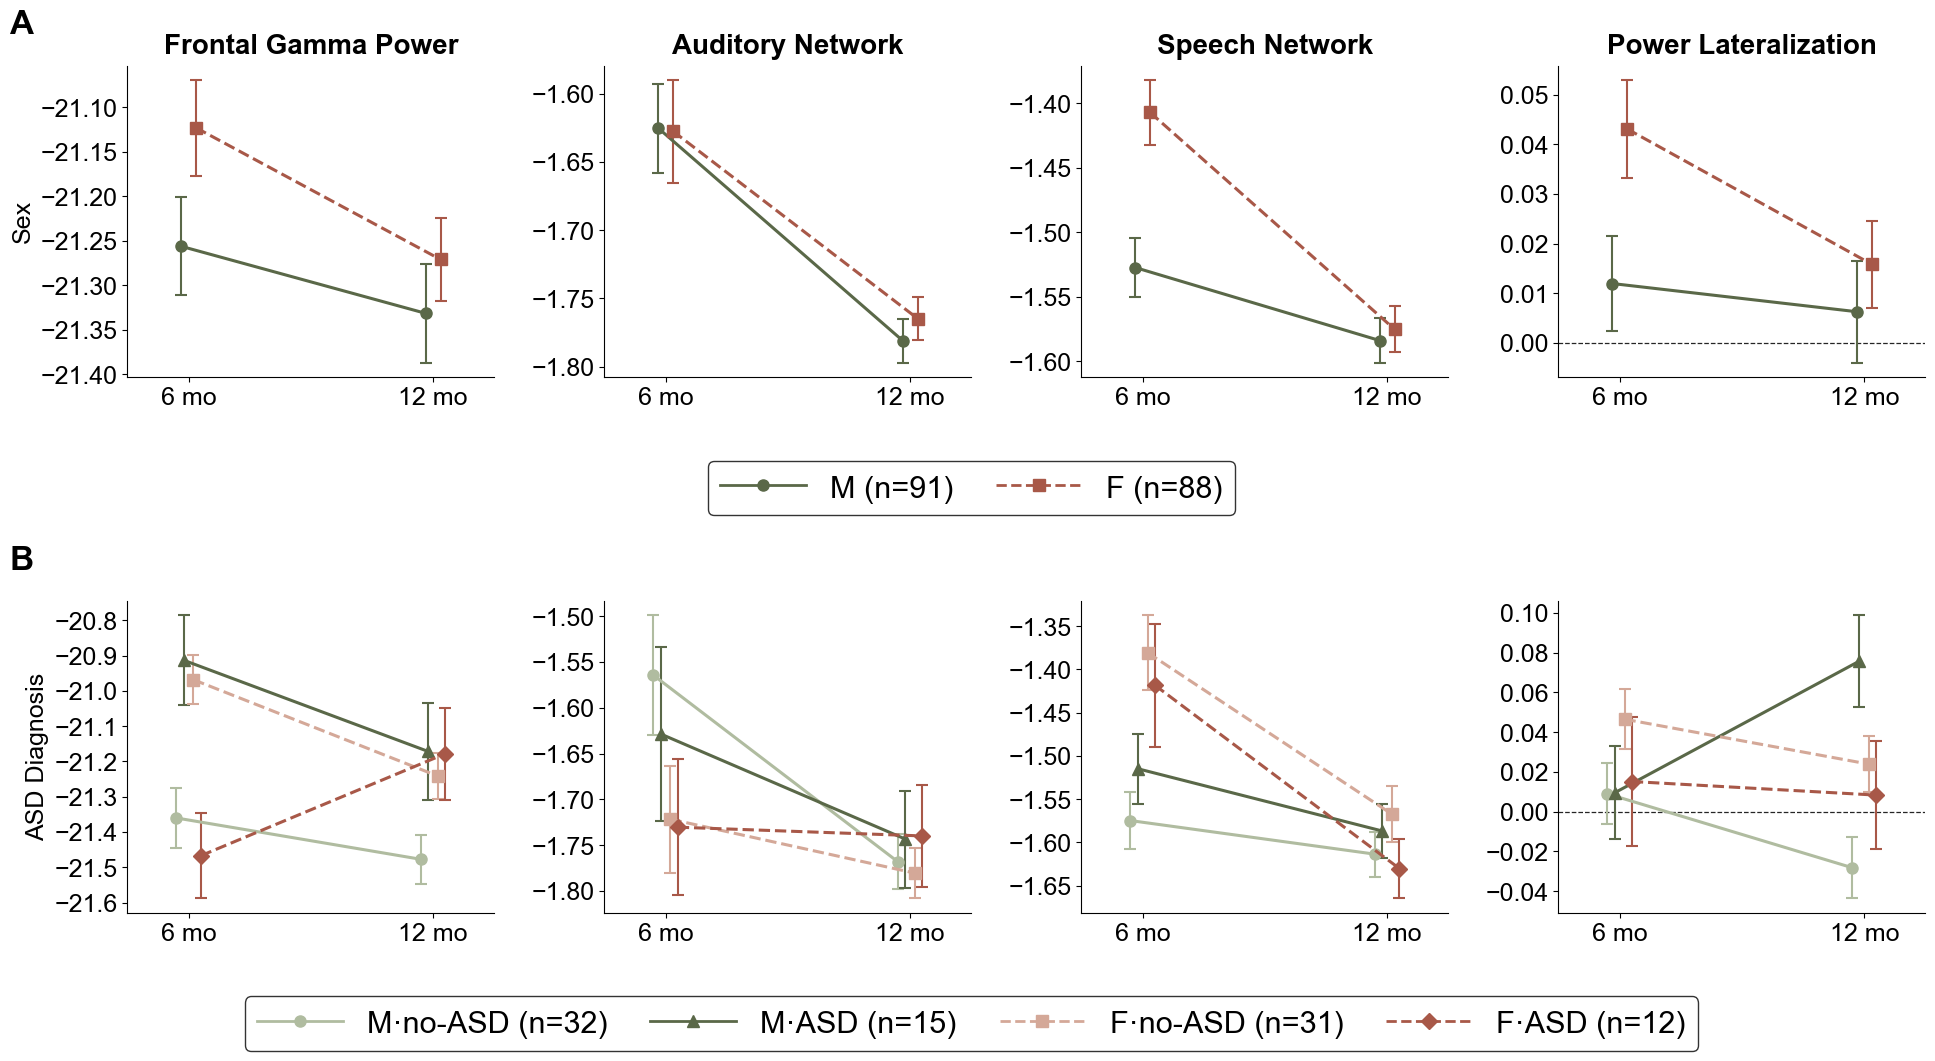

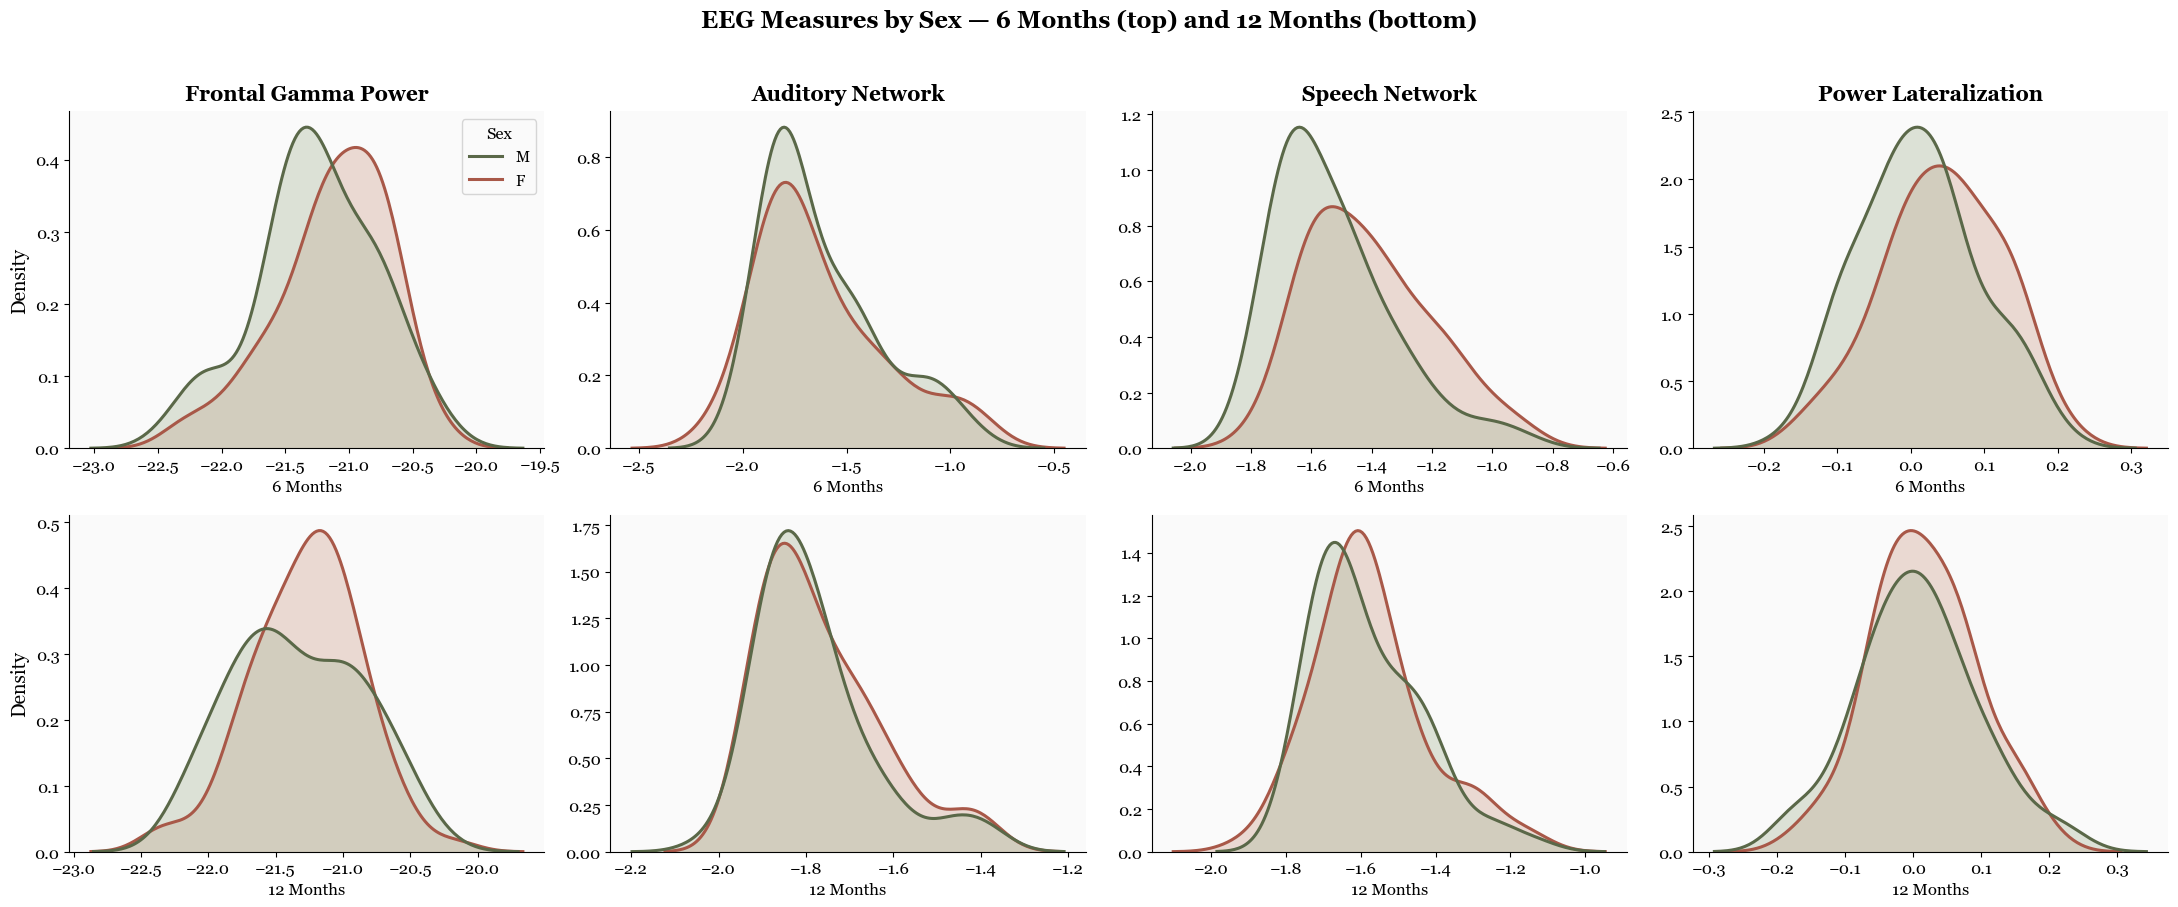

In [32]:
fig2, axs2 = plt.subplots(2, 4, figsize=(5.8 * 4, 5.5 * 2),
                           gridspec_kw={'hspace': 0.72, 'wspace': 0.30})

# Accumulators for perrow legend handles
row_handles2 = [[], []]

for col_idx, metric in enumerate(metric_names):
    cols   = metrics[metric]
    is_lat = (metric == 'Power Lateralization')

    def zero_line(ax):
        if is_lat:
            ax.axhline(0, color="#252525", linewidth=0.9, linestyle='--', zorder=-1)

 # ROW 0 Sex
    ax = axs2[0, col_idx]
    sex_dodge = {'M': -0.03, 'F': 0.03}
    for grp in sex_order:
        sub   = plotting_df[plotting_df['sex'] == grp]
        means = [sub[c].mean() for c in cols]
        sems  = [sub[c].sem()  for c in cols]
        x_plot = [x + sex_dodge[grp] for x in x_pos]
        ax.errorbar(x_plot, means, yerr=sems,
                    color=sex_palette[grp], linestyle=sex_ls[grp],
                    marker=sex_marker[grp], markersize=8, linewidth=2.2,
                    capsize=4, capthick=1.5, elinewidth=1.5)
        if col_idx == 0:
            row_handles2[0].append(
                Line2D([0],[0], color=sex_palette[grp], linestyle=sex_ls[grp],
                       marker=sex_marker[grp], markersize=8, linewidth=2,
                       label=f'{grp} (n={n_sex[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.25, 1.25)
    ax.set_title(metric, pad=9)
    ax.set_ylabel('Sex' if col_idx == 0 else '')

 # ROW 1 ASD Diagnosis (ELA only)
    ax = axs2[1, col_idx]
    dx_dodge = {'M·no-ASD': -0.05, 'M·ASD': -0.02, 'F·no-ASD': 0.02, 'F·ASD': 0.05}
    for grp in dx_order:
        sub   = plot_dx[plot_dx['sex_dx'] == grp]
        means = [sub[c].mean() for c in cols]
        sems  = [sub[c].sem()  for c in cols]
        x_plot = [x + dx_dodge[grp] for x in x_pos]
        ax.errorbar(x_plot, means, yerr=sems,
                    color=dx_palette[grp], linestyle=dx_ls[grp],
                    marker=dx_marker[grp], markersize=8, linewidth=2.2,
                    capsize=4, capthick=1.5, elinewidth=1.5)
        if col_idx == 0:
            row_handles2[1].append(
                Line2D([0],[0], color=dx_palette[grp], linestyle=dx_ls[grp],
                       marker=dx_marker[grp], markersize=8, linewidth=2,
                       label=f'{grp} (n={n_dx[grp]})'))
    zero_line(ax)
    ax.set_xticks(x_pos); ax.set_xticklabels(tp_labels)
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylabel('ASD Diagnosis' if col_idx == 0 else '')

# Panel letters

for row_idx, letter in enumerate(['A', 'B']):
    axs2[row_idx, 0].text(
        -0.32, 1.18, letter,
        transform=axs2[row_idx, 0].transAxes,
        fontsize=24, fontweight='bold', va='top', ha='left',
        fontfamily='sans-serif',
    )

# Horizontal legends one per row, centred below

for row_idx, handles in enumerate(row_handles2):
    axs2[row_idx, 1].legend(
        handles=handles, title=None,
        loc='upper center',
        bbox_to_anchor=(1.0, -0.22),
        ncol=len(handles),
        frameon=True, facecolor='white', edgecolor='black',
        fontsize=22,
        handlelength=2.8, handleheight=1.0,
        columnspacing=1.4,
    )

# Save

 # Twopass KDE: pale fill + darker outline muted olive / faded brick palette
plt.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size':             14,
    'axes.titlesize':        15,
    'axes.titleweight':      'bold',
    'axes.labelsize':        13,
    'xtick.labelsize':       12,
    'ytick.labelsize':       12,
    'legend.fontsize':       12,
    'legend.title_fontsize': 12,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.facecolor':      'white',
    'axes.facecolor':        '#fafafa',
})

# Pale fill colours matches M_LIGHT / F_LIGHT from main palette
sex_palette      = {'M': M_LIGHT, 'F': F_LIGHT}   # '#B0BCA0', '#D4A898'
# Darker outline colours matches M_DARK / F_DARK from main palette
sex_line_palette = {'M': M_DARK,  'F': F_DARK}    # '#5A6848', '#A85848'

sex_order = ['M', 'F']

# 4 focal metrics: (display name, 6mo col, 12mo col)
focal_metrics_hist = [
    ('Frontal Gamma Power', 'Frontal Gamma Power 6mo', 'Frontal Gamma Power 12mo'),
    ('Auditory Network',    'Auditory Network 6mo',    'Auditory Network 12mo'),
    ('Speech Network',      'Speech Network 6mo',      'Speech Network 12mo'),
    ('Power Lateralization','Power Lateralization 6mo', 'Power Lateralization 12mo'),
]

fig, axs = plt.subplots(2, 4, figsize=(5.5 * 4, 4.5 * 2))

for col_idx, (metric_name, col_6, col_12) in enumerate(focal_metrics_hist):
    for row_idx, (col, tp_label) in enumerate([(col_6, '6 Months'), (col_12, '12 Months')]):
        ax = axs[row_idx, col_idx]
        if col not in plotting_df.columns:
            ax.set_visible(False)
            continue
        data = plotting_df.dropna(subset=[col, 'sex'])

 # Pass 1: pale filled area, no visible outline
        sns.kdeplot(
            data=data, x=col, hue='sex',
            hue_order=sex_order,
            palette=sex_palette,
            fill=True, alpha=0.40, linewidth=0,
            ax=ax,
        )
 # Pass 2: darker outline line only (no fill)
        sns.kdeplot(
            data=data, x=col, hue='sex',
            hue_order=sex_order,
            palette=sex_line_palette,
            fill=False, linewidth=2.2,
            ax=ax,
        )

        if row_idx == 0:
            ax.set_title(metric_name, pad=8)
        ax.set_xlabel(tp_label, fontsize=12)
        ax.set_ylabel('Density' if col_idx == 0 else '')

 # Keep only the topleft legend; remove duplicates from pass 2
        legends = ax.get_legend()
        if legends:
            if row_idx == 0 and col_idx == 0:
                legends.set_title('Sex')
                legends.get_title().set_fontsize(12)
                for txt in legends.get_texts():
                    txt.set_fontsize(11)
            else:
                legends.remove()

fig.suptitle('EEG Measures by Sex — 6 Months (top) and 12 Months (bottom)',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S5_eeg_sex_diff_histograms.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **Supplementary S6** EEG diatributions for ASD vs no ASD, trajectoreis 6-18mo

C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\1848738024.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\1848738024.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\1848738024.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gabot\AppData\Local\Temp\ipykernel_44332\1848738024.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

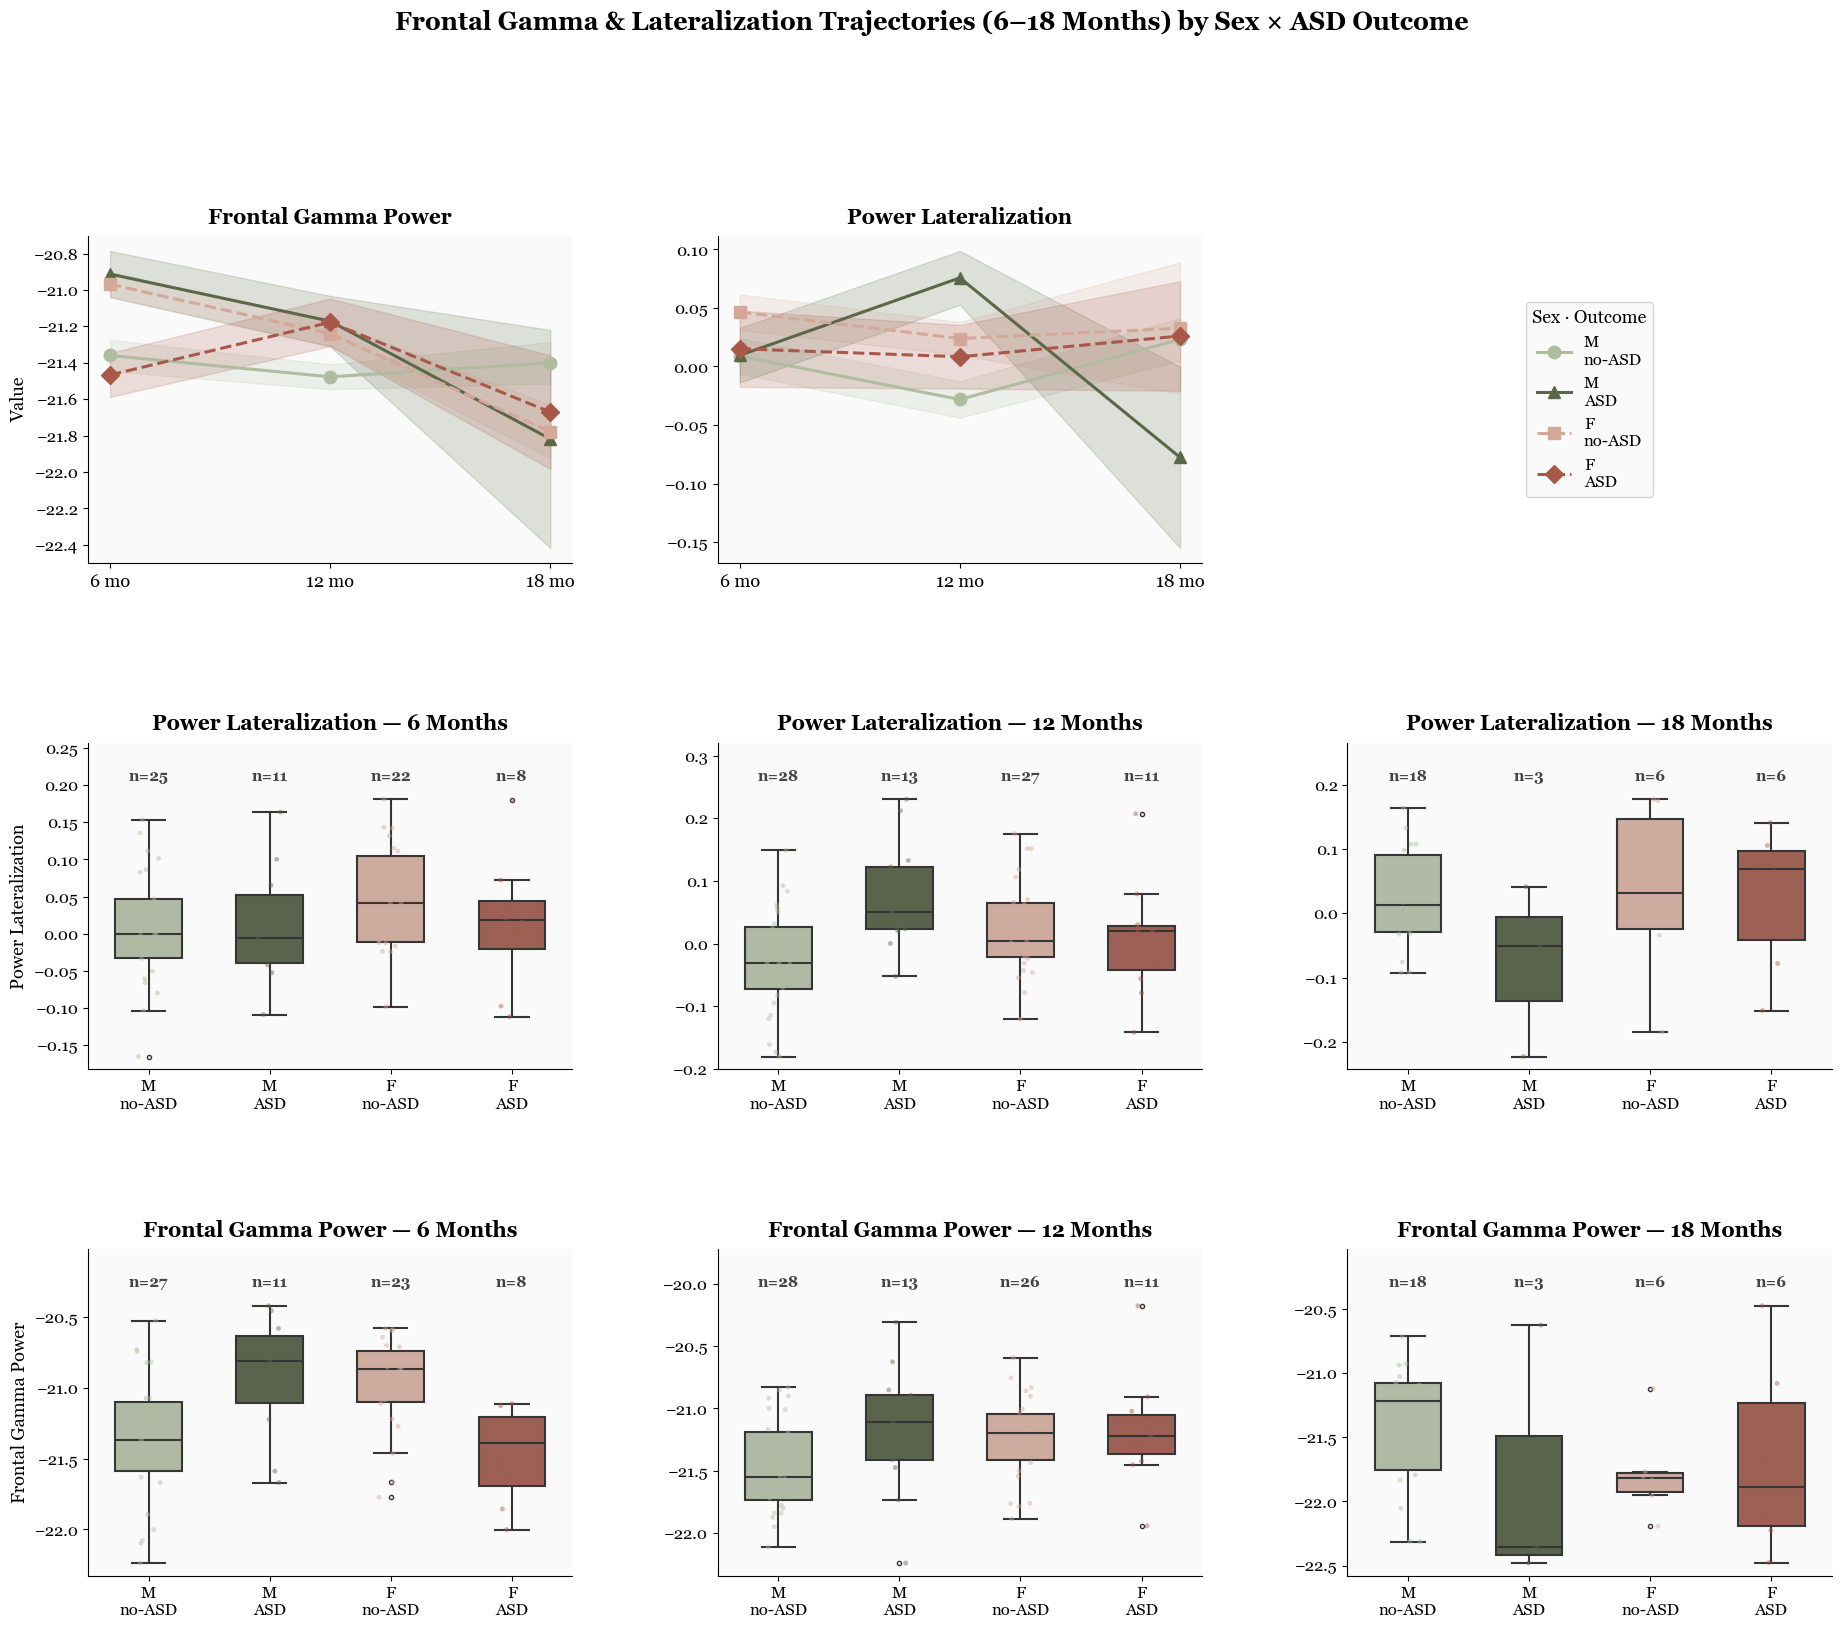

In [33]:
# EEG trajectories (6 → 12 → 18 months): Frontal Gamma Power and Power Lateralization


outcome_order  = ['M · no-ASD', 'M · ASD', 'F · no-ASD', 'F · ASD']
outcome_labels = ['M\nno-ASD',   'M\nASD',   'F\nno-ASD',   'F\nASD']

outcome_palette = {
    'M · no-ASD': M_LIGHT,
    'M · ASD':    M_DARK,
    'F · no-ASD': F_LIGHT,
    'F · ASD':    F_DARK,
}
line_styles = {
    'M · no-ASD': '-',
    'M · ASD':    '-',
    'F · no-ASD': '--',
    'F · ASD':    '--',
}
markers_map = {
    'M · no-ASD': 'o',
    'M · ASD':    '^',
    'F · no-ASD': 's',
    'F · ASD':    'D',
}

# Build plot3: ELA participants with sex × ASD outcome group column
plot3 = plotting_df[plotting_df['group_type'] == 'ELA'].dropna(subset=['sex', 'outcome']).copy()
plot3['sex_outcome'] = (
    plot3['sex'] + ' · ' +
    plot3['outcome'].str.replace('asd', 'ASD', case=False)
                    .str.replace('no-asd', 'no-ASD', case=False)
                    .str.replace('No-ASD', 'no-ASD')
)
plot3['sex_outcome'] = pd.Categorical(plot3['sex_outcome'],
                                       categories=outcome_order, ordered=True)

# Focal metrics with 3 timepoints
focal_traj_18 = {
    'Frontal Gamma Power': [
        'Frontal Gamma Power 6mo',
        'Frontal Gamma Power 12mo',
        'Frontal Gamma Power 18mo',
    ],
    'Power Lateralization': [
        'Power Lateralization 6mo',
        'Power Lateralization 12mo',
        'Power Lateralization 18mo',
    ],
}

fig4, axs4 = plt.subplots(3, 3, figsize=(7.5 * 3, 5.8 * 3),
                           gridspec_kw={'height_ratios': [1, 1, 1],
                                        'hspace': 0.55, 'wspace': 0.30})

# Row 0: trajectory line plots (3 timepoints)
for ax_idx, (measure_name, cols) in enumerate(focal_traj_18.items()):
    ax = axs4[0, ax_idx]
    x_pos = list(range(len(cols)))

    for group in outcome_order:
        grp   = plot3[plot3['sex_outcome'] == group]
        means = [grp[c].mean() for c in cols]
        sems  = [grp[c].sem()  for c in cols]
        color = outcome_palette[group]
        ax.plot(x_pos, means,
                color=color, linestyle=line_styles[group],
                marker=markers_map[group], markersize=9,
                linewidth=2.2, label=group.replace(' · ', '\n'))
        ax.fill_between(x_pos,
                        [m - s for m, s in zip(means, sems)],
                        [m + s for m, s in zip(means, sems)],
                        color=color, alpha=0.18)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['6 mo', '12 mo', '18 mo'], fontsize=13)
    ax.set_title(measure_name, fontsize=15, fontweight='bold', pad=9)
    ax.set_ylabel('Value' if ax_idx == 0 else '', fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend in the third top panel (no plot)
handles_leg, labels_leg = axs4[0, 0].get_legend_handles_labels()
axs4[0, 2].legend(handles_leg, labels_leg,
                  title='Sex · Outcome', fontsize=12, title_fontsize=13,
                  framealpha=0.85, loc='center')
axs4[0, 2].axis('off')

# Row 1: Power Lateralization boxplots
for tp_idx, (tp_col, tp_label) in enumerate([
    ('Power Lateralization 6mo',  '6 Months'),
    ('Power Lateralization 12mo', '12 Months'),
    ('Power Lateralization 18mo', '18 Months'),
]):
    ax = axs4[1, tp_idx]
    valid = plot3.dropna(subset=[tp_col])

    sns.boxplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        width=0.55, linewidth=1.5, fliersize=3, ax=ax,
    )
    sns.stripplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        size=3.5, alpha=0.45, jitter=True, ax=ax,
    )

    y_max   = valid[tp_col].max()
    y_range = valid[tp_col].max() - valid[tp_col].min()
    for g_idx, group in enumerate(outcome_order):
        n = (valid['sex_outcome'] == group).sum()
        ax.text(g_idx, y_max + y_range * 0.06, f'n={n}',
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='#444444')
    ax.set_ylim(top=y_max + y_range * 0.22)
    ax.set_xticks(range(len(outcome_order)))
    ax.set_xticklabels(outcome_labels, fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'Power Lateralization — {tp_label}',
                 fontsize=15, fontweight='bold', pad=9)
    ax.set_ylabel('Power Lateralization' if tp_idx == 0 else '', fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Row 2: Frontal Gamma Power boxplots
for tp_idx, (tp_col, tp_label) in enumerate([
    ('Frontal Gamma Power 6mo',  '6 Months'),
    ('Frontal Gamma Power 12mo', '12 Months'),
    ('Frontal Gamma Power 18mo', '18 Months'),
]):
    ax = axs4[2, tp_idx]
    valid = plot3.dropna(subset=[tp_col])

    sns.boxplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        width=0.55, linewidth=1.5, fliersize=3, ax=ax,
    )
    sns.stripplot(
        data=valid, x='sex_outcome', y=tp_col,
        order=outcome_order, palette=outcome_palette,
        size=3.5, alpha=0.45, jitter=True, ax=ax,
    )

    y_max   = valid[tp_col].max()
    y_range = valid[tp_col].max() - valid[tp_col].min()
    for g_idx, group in enumerate(outcome_order):
        n = (valid['sex_outcome'] == group).sum()
        ax.text(g_idx, y_max + y_range * 0.06, f'n={n}',
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='#444444')
    ax.set_ylim(top=y_max + y_range * 0.22)
    ax.set_xticks(range(len(outcome_order)))
    ax.set_xticklabels(outcome_labels, fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'Frontal Gamma Power — {tp_label}',
                 fontsize=15, fontweight='bold', pad=9)
    ax.set_ylabel('Frontal Gamma Power' if tp_idx == 0 else '', fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig4.suptitle(
    'Frontal Gamma & Lateralization Trajectories (6–18 Months) by Sex × ASD Outcome',
    fontsize=18, fontweight='bold', y=1.01
)
plt.tight_layout()

os.makedirs('../../figures/supplementary/', exist_ok=True)
plt.savefig('../../figures/supplementary/S6_eeg_focal_trajectories_18mo_sex_asd_outcome.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
